# Modified TPGMM for Gait Data with Transformed Reference Frame

In [1]:
import sys
import os

import json
import numpy as np
import matplotlib.pyplot as plt

In [2]:
parent_dir = os.path.dirname(os.getcwd())
sys.path.append(parent_dir)

print(parent_dir)
print(os.getcwd())

/home/jemajuinta/ws/Gait-analysis-coupled/TaskPaGMMM
/home/jemajuinta/ws/Gait-analysis-coupled/TaskPaGMMM/examples


In [3]:
from tpgmm.tpgmm.tpgmm import TPGMM
from tpgmm.gmr.gmr import GaussianMixtureRegression
from tpgmm.utils.plot.plot import plot_trajectories, plot_ellipsoids, scatter
from tpgmm.utils.plot.plot import plot_trajectories_2d, plot_ellipsoids_2d

In [4]:
with open("7days1/gait_analysis_export_subject35v3.json", "r") as f:
    data = json.load(f)

# Data loading completed above - this cell is now obsolete

Trajectories manipulation

In [5]:
# Create separate lists for trajectories from each frame of reference
trajectories_fr1 = []
trajectories_fr2 = []

# Access kinematics data for FR1 and FR2
fr1_data = data['kinematics_data']['FR1']['right_leg_kinematics']
fr2_data = data['kinematics_data']['FR2']['right_leg_kinematics']

for demo_fr1, demo_fr2 in zip(fr1_data, fr2_data):
    # For FR1: right ankle position, velocity, and angle data with time
    pos_fr1 = np.array(demo_fr1['right_ankle_pos']).T  # Shape: (200, 2)
    vel_fr1 = np.array(demo_fr1['right_ankle_vel']).T  # Shape: (200, 2)
    ankle_right_deg_fr1 = np.array(demo_fr1['ankle_right_deg']).reshape(-1, 1)  # Shape: (200, 1)
    ankle_left_deg_fr1 = np.array(demo_fr1['ankle_left_deg']).reshape(-1, 1)   # Shape: (200, 1)
    
    # Create time vector for this demonstration
    num_steps = pos_fr1.shape[0]
    time_demo = np.linspace(0, 1, num_steps).reshape(-1, 1)
    
    # Stack features: [x_pos, y_pos, x_vel, y_vel, ankle_right_deg, ankle_left_deg, time]
    traj1 = np.hstack([pos_fr1, vel_fr1, ankle_right_deg_fr1, ankle_left_deg_fr1, time_demo])
    trajectories_fr1.append(traj1)
    
    # For FR2: right ankle position, velocity, and angle data with time
    pos_fr2 = np.array(demo_fr2['right_ankle_pos']).T  # Shape: (200, 2)
    vel_fr2 = np.array(demo_fr2['right_ankle_vel']).T  # Shape: (200, 2)
    ankle_right_deg_fr2 = np.array(demo_fr2['ankle_right_deg']).reshape(-1, 1)  # Shape: (200, 1)
    ankle_left_deg_fr2 = np.array(demo_fr2['ankle_left_deg']).reshape(-1, 1)   # Shape: (200, 1)
    
    # Stack features: [x_pos, y_pos, x_vel, y_vel, ankle_right_deg, ankle_left_deg, time]
    traj2 = np.hstack([pos_fr2, vel_fr2, ankle_right_deg_fr2, ankle_left_deg_fr2, time_demo])
    trajectories_fr2.append(traj2)

# Convert lists to numpy arrays
trajectories_fr1 = np.array(trajectories_fr1)
trajectories_fr2 = np.array(trajectories_fr2)

print(f"Trajectories FR1 shape: {trajectories_fr1.shape}")
print(f"Trajectories FR2 shape: {trajectories_fr2.shape}")
print(f"Number of demonstrations: {len(trajectories_fr1)}")
print(f"Features: [x_pos, y_pos, x_vel, y_vel, ankle_right_deg, ankle_left_deg, time]")

Trajectories FR1 shape: (11, 200, 7)
Trajectories FR2 shape: (11, 200, 7)
Number of demonstrations: 11
Features: [x_pos, y_pos, x_vel, y_vel, ankle_right_deg, ankle_left_deg, time]


In [6]:
# Use original FR2 trajectories without any artificial rotation
print("✅ Using original FR1 and FR2 trajectories")
print("="*50)

# Note: FR1 and FR2 naturally have different orientations based on their reference frames
# This is the intended behavior for TPGMM - different frames should have different orientations

print(f"FR1 trajectories shape: {trajectories_fr1.shape}")
print(f"FR2 trajectories shape: {trajectories_fr2.shape}")
print(f"Number of demonstrations: {len(trajectories_fr1)}")
print(f"Features: [x_pos, y_pos, x_vel, y_vel, ankle_right_deg, ankle_left_deg, time]")
print("FR1 and FR2 have their natural different orientations as expected")

✅ Using original FR1 and FR2 trajectories
FR1 trajectories shape: (11, 200, 7)
FR2 trajectories shape: (11, 200, 7)
Number of demonstrations: 11
Features: [x_pos, y_pos, x_vel, y_vel, ankle_right_deg, ankle_left_deg, time]
FR1 and FR2 have their natural different orientations as expected


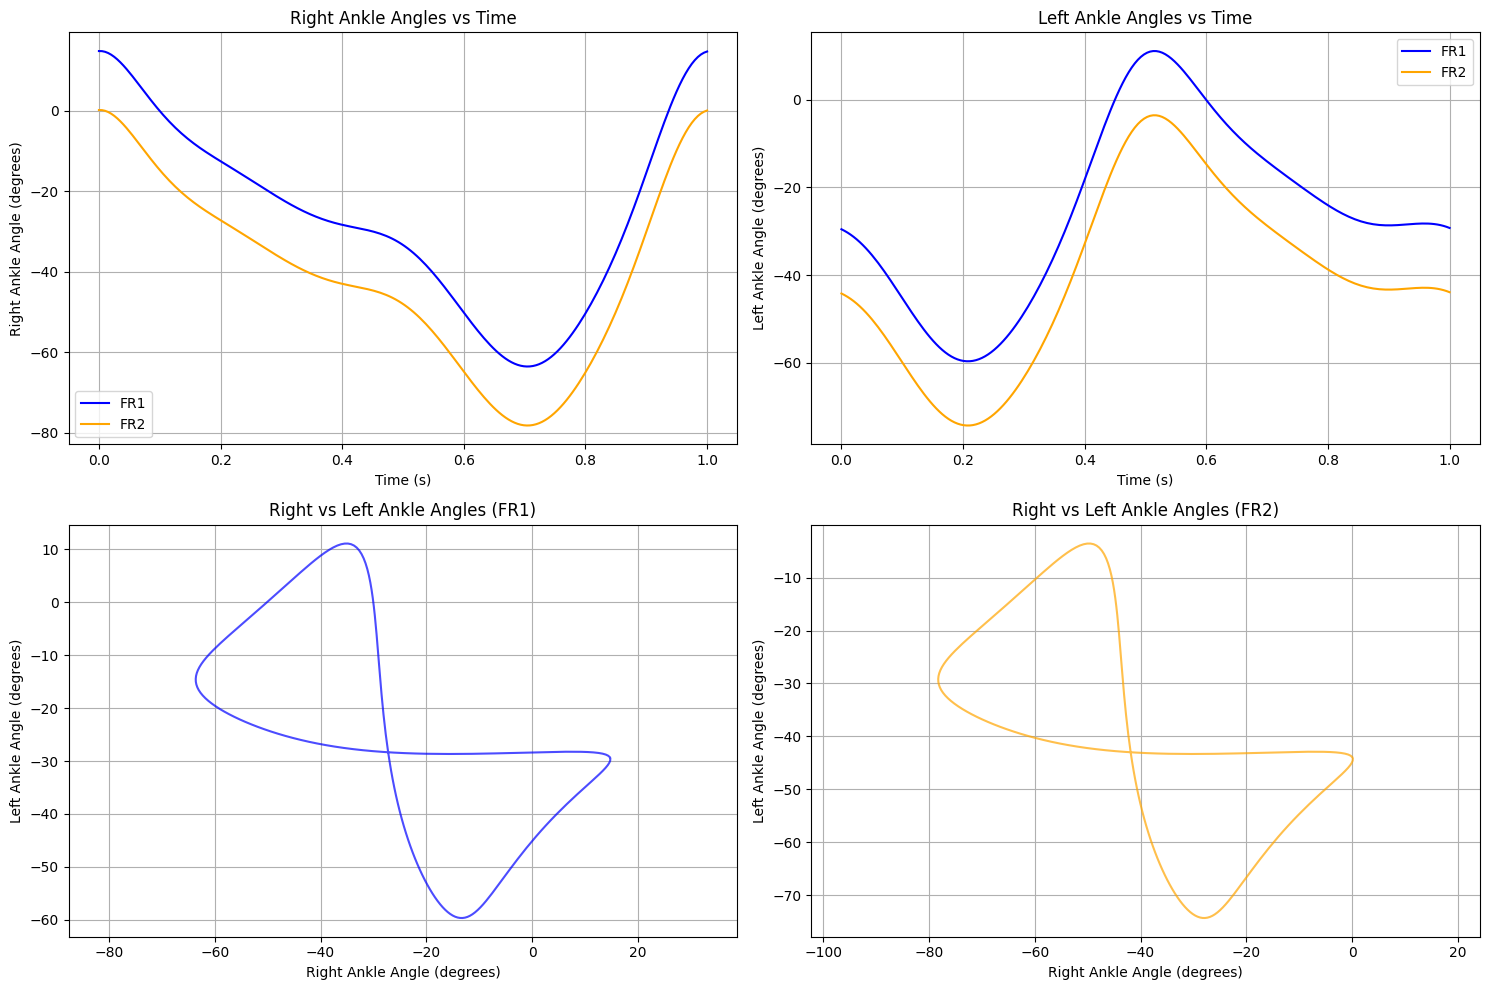

✅ Ankle angle features added successfully!
Right ankle angle range FR1: [-63.6, 14.8] degrees
Left ankle angle range FR1: [-59.7, 11.1] degrees


In [7]:
# Let's also plot the ankle angles to visualize the new features
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot ankle right angles over time for both frames
axes[0, 0].set_title('Right Ankle Angles vs Time')
axes[0, 0].plot(trajectories_fr1[0][:, -1], trajectories_fr1[0][:, 4], label='FR1', color='blue')
axes[0, 0].plot(trajectories_fr2[0][:, -1], trajectories_fr2[0][:, 4], label='FR2', color='orange') 
axes[0, 0].set_xlabel('Time (s)')
axes[0, 0].set_ylabel('Right Ankle Angle (degrees)')
axes[0, 0].legend()
axes[0, 0].grid()

# Plot ankle left angles over time for both frames
axes[0, 1].set_title('Left Ankle Angles vs Time')
axes[0, 1].plot(trajectories_fr1[0][:, -1], trajectories_fr1[0][:, 5], label='FR1', color='blue')
axes[0, 1].plot(trajectories_fr2[0][:, -1], trajectories_fr2[0][:, 5], label='FR2', color='orange')
axes[0, 1].set_xlabel('Time (s)')
axes[0, 1].set_ylabel('Left Ankle Angle (degrees)')
axes[0, 1].legend()
axes[0, 1].grid()

# Plot right vs left ankle angles for FR1
axes[1, 0].set_title('Right vs Left Ankle Angles (FR1)')
axes[1, 0].plot(trajectories_fr1[0][:, 4], trajectories_fr1[0][:, 5], 'b-', alpha=0.7)
axes[1, 0].set_xlabel('Right Ankle Angle (degrees)')
axes[1, 0].set_ylabel('Left Ankle Angle (degrees)')
axes[1, 0].grid()
axes[1, 0].axis('equal')

# Plot right vs left ankle angles for FR2  
axes[1, 1].set_title('Right vs Left Ankle Angles (FR2)')
axes[1, 1].plot(trajectories_fr2[0][:, 4], trajectories_fr2[0][:, 5], 'orange', alpha=0.7)
axes[1, 1].set_xlabel('Right Ankle Angle (degrees)')
axes[1, 1].set_ylabel('Left Ankle Angle (degrees)')
axes[1, 1].grid()
axes[1, 1].axis('equal')

plt.tight_layout()
plt.show()

print("✅ Ankle angle features added successfully!")
print(f"Right ankle angle range FR1: [{trajectories_fr1[0][:, 4].min():.1f}, {trajectories_fr1[0][:, 4].max():.1f}] degrees")
print(f"Left ankle angle range FR1: [{trajectories_fr1[0][:, 5].min():.1f}, {trajectories_fr1[0][:, 5].max():.1f}] degrees")

Ploting Input Data

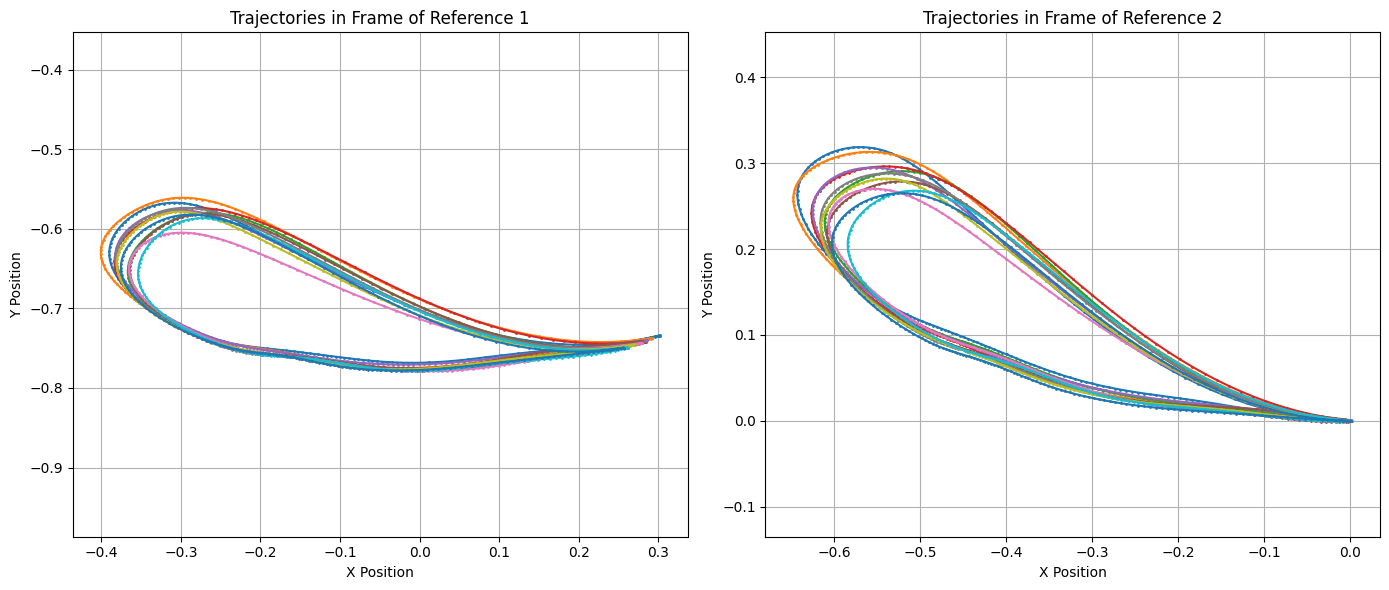

In [8]:
# --- Plotting ---
# Create a figure with two subplots, side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot trajectories for Frame of Reference 1
ax1.set_title('Trajectories in Frame of Reference 1')
ax1.set_xlabel('X Position')
ax1.set_ylabel('Y Position')
for traj in trajectories_fr1:
    # The first two columns are x and y ankle positions
    x_pos = traj[:, 0]
    y_pos = traj[:, 1]
    ax1.plot(x_pos, y_pos, marker='.', linestyle='-', markersize=2)
ax1.grid(True)
ax1.axis('equal')

# Plot trajectories for Frame of Reference 2
ax2.set_title('Trajectories in Frame of Reference 2')
ax2.set_xlabel('X Position')
ax2.set_ylabel('Y Position')
for traj in trajectories_fr2:
    # The first two columns are x and y ankle positions
    x_pos = traj[:, 0]
    y_pos = traj[:, 1]
    ax2.plot(x_pos, y_pos, marker='.', linestyle='-', markersize=2)
ax2.grid(True)
ax2.axis('equal')

# Show the plots
fig.tight_layout()
plt.show()

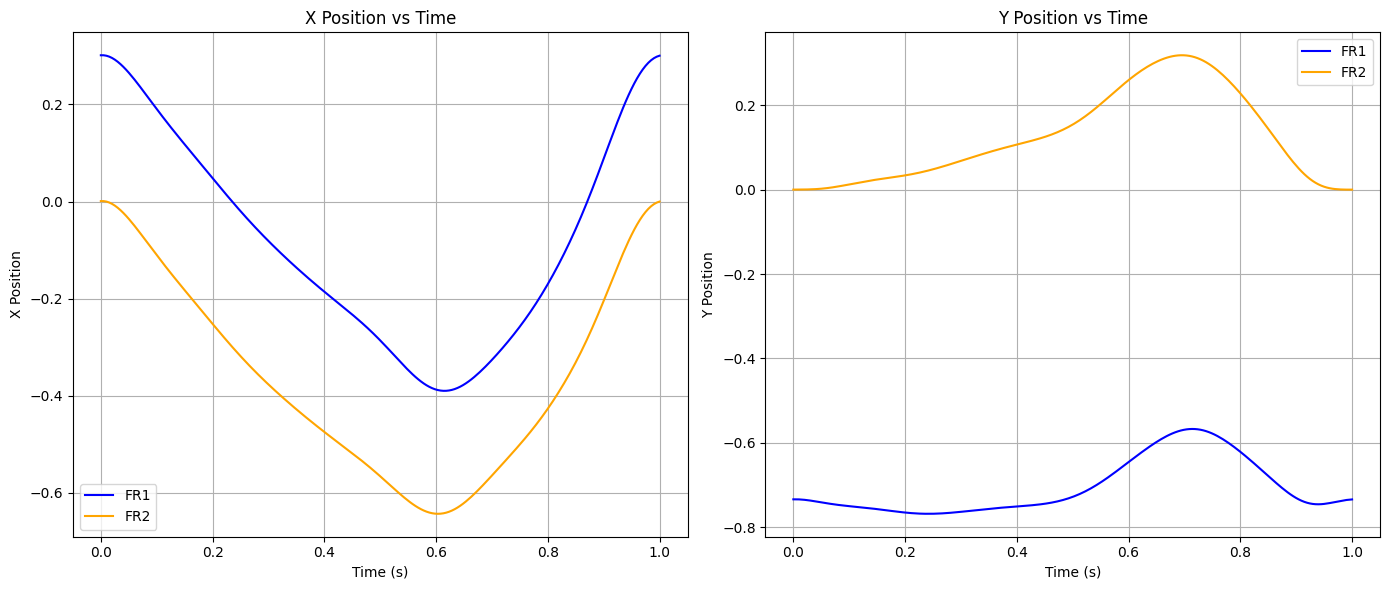

In [9]:
# Create the figure and subplots
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Plot X vs Time (time is now at index -1, which is index 6)
axs[0].plot(trajectories_fr1[0][:, -1], trajectories_fr1[0][:, 0], label='FR1', color='blue')
axs[0].plot(trajectories_fr2[0][:, -1], trajectories_fr2[0][:, 0], label='FR2', color='orange')
axs[0].set_title('X Position vs Time')
axs[0].set_xlabel('Time (s)')
axs[0].set_ylabel('X Position')
axs[0].legend()
axs[0].grid()

# Plot Y vs Time
axs[1].plot(trajectories_fr1[0][:, -1], trajectories_fr1[0][:, 1], label='FR1', color='blue')
axs[1].plot(trajectories_fr2[0][:, -1], trajectories_fr2[0][:, 1], label='FR2', color='orange')
axs[1].set_title('Y Position vs Time')
axs[1].set_xlabel('Time (s)')
axs[1].set_ylabel('Y Position')
axs[1].legend()
axs[1].grid()

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

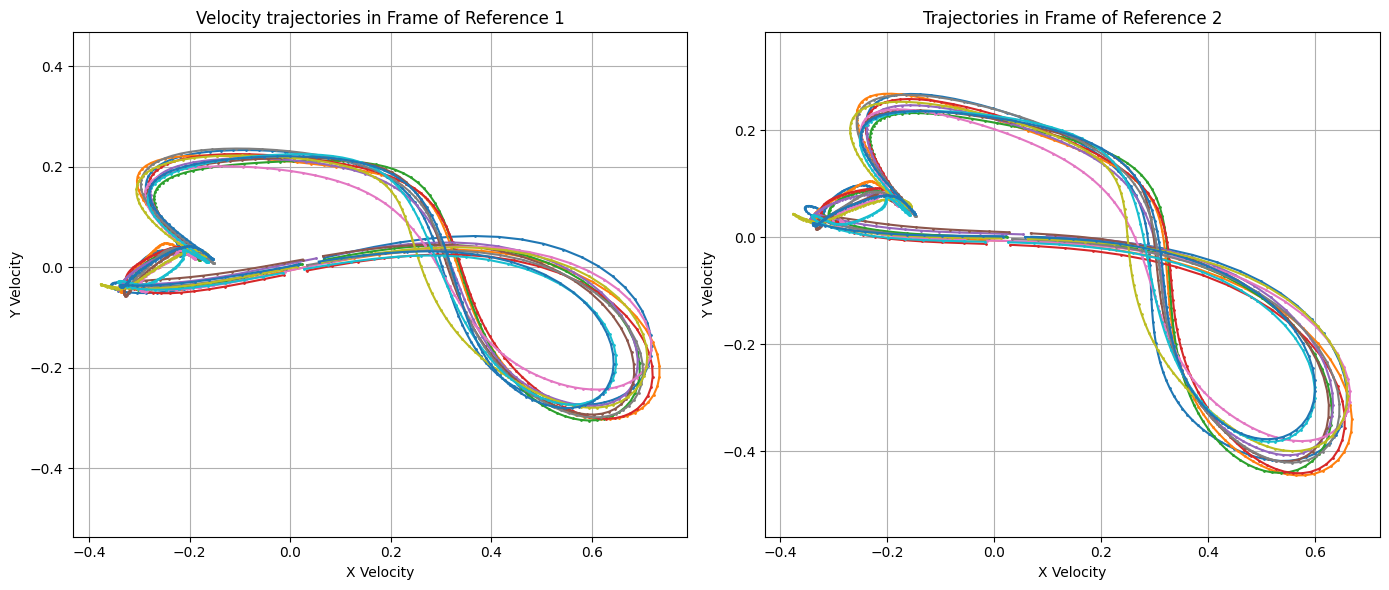

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot velocity trajectories for Frame of Reference 1
ax1.set_title('Velocity trajectories in Frame of Reference 1')
ax1.set_xlabel('X Velocity')
ax1.set_ylabel('Y Velocity')
for traj in trajectories_fr1:
    # Velocity features are at indices 2 and 3
    x_vel = traj[:, 2]
    y_vel = traj[:, 3]
    ax1.plot(x_vel, y_vel, marker='.', linestyle='-', markersize=2)
ax1.grid(True)
ax1.axis('equal')

# Plot velocity trajectories for Frame of Reference 2
ax2.set_title('Trajectories in Frame of Reference 2')
ax2.set_xlabel('X Velocity')
ax2.set_ylabel('Y Velocity')
for traj in trajectories_fr2:
    # Velocity features are at indices 2 and 3
    x_vel = traj[:, 2]
    y_vel = traj[:, 3]
    ax2.plot(x_vel, y_vel, marker='.', linestyle='-', markersize=2)
ax2.grid(True)
ax2.axis('equal')

# Show the plots
plt.tight_layout()
plt.show()

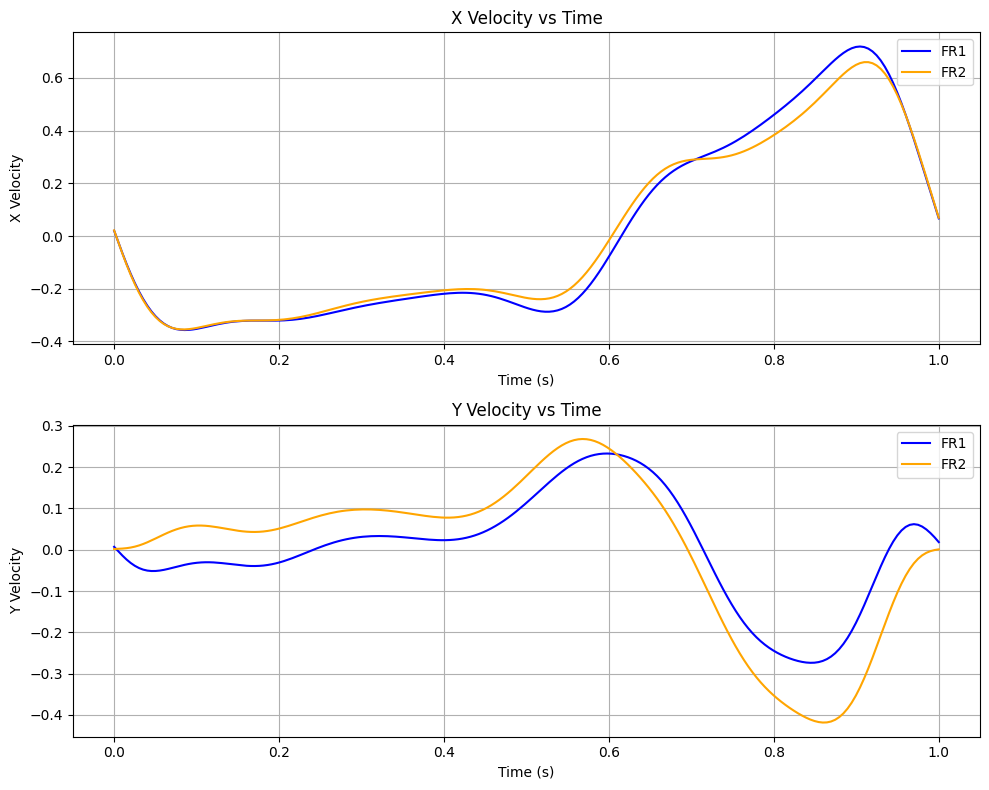

In [11]:
# Create the figure and subplots for velocity plots
fig, axs = plt.subplots(2, 1, figsize=(10, 8))

# Plot X velocity vs Time (velocity indices are 2 and 3)
axs[0].plot(trajectories_fr1[0][:, -1], trajectories_fr1[0][:, 2], label='FR1', color='blue')
axs[0].plot(trajectories_fr2[0][:, -1], trajectories_fr2[0][:, 2], label='FR2', color='orange')
axs[0].set_title('X Velocity vs Time')
axs[0].set_xlabel('Time (s)')
axs[0].set_ylabel('X Velocity')
axs[0].legend()
axs[0].grid()

# Plot Y velocity vs Time
axs[1].plot(trajectories_fr1[0][:, -1], trajectories_fr1[0][:, 3], label='FR1', color='blue')
axs[1].plot(trajectories_fr2[0][:, -1], trajectories_fr2[0][:, 3], label='FR2', color='orange')
axs[1].set_title('Y Velocity vs Time')
axs[1].set_xlabel('Time (s)')
axs[1].set_ylabel('Y Velocity')
axs[1].legend()
axs[1].grid()

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

In [ ]:
# Calculating the translation vectors and rotation matrices for FR2
# USING trajectories_fr1[0] and trajectories_fr2[0]
# TRANSFORMING FR2 to match FR1 (inverse transformation)

print("🔍 COMPREHENSIVE TRANSFORMATION ANALYSIS")
print("TRANSFORMING FR2 TO MATCH FR1")
print("="*60)

# Extract reference trajectories for detailed analysis
trajectory_fr1_ref = trajectories_fr1[0]  # Reference trajectory from FR1
trajectory_fr2_ref = trajectories_fr2[0]  # Corresponding trajectory from FR2

print(f"Using trajectory 0 as reference for transformation analysis")
print(f"FR1 trajectory shape: {trajectory_fr1_ref.shape}")
print(f"FR2 trajectory shape: {trajectory_fr2_ref.shape}")

# FIRST: Find the mean difference in position x and position y from FR2 to FR1, dims [0,1]
print(f"\\n1️⃣ POSITION TRANSLATION ANALYSIS (dims [0,1]):")
print("   Finding translation to transform FR2 → FR1")

pos_fr1 = trajectory_fr1_ref[:, :2]  # x, y positions
pos_fr2 = trajectory_fr2_ref[:, :2]  # x, y positions

# Calculate position differences at each time step (FR1 - FR2 for inverse transform)
position_differences = pos_fr1 - pos_fr2

# Calculate mean translation (FR2 → FR1)
mean_position_translation = np.mean(position_differences, axis=0)

print(f"   - Position differences shape: {position_differences.shape}")
print(f"   - Mean position translation (FR2→FR1): [{mean_position_translation[0]:.4f}, {mean_position_translation[1]:.4f}]")
print(f"   - Position translation magnitude: {np.linalg.norm(mean_position_translation):.4f}")

# SECOND: Find the mean difference in orientation angle from FR2 to FR1 using dims [4] and [5] separately
print(f"\\n2️⃣ ANKLE ANGLE ORIENTATION ANALYSIS (dims [4], [5]):")
print("   Finding angle shifts to transform FR2 → FR1")

ankle_right_fr1 = trajectory_fr1_ref[:, 4]  # Right ankle angles FR1
ankle_right_fr2 = trajectory_fr2_ref[:, 4]  # Right ankle angles FR2
ankle_left_fr1 = trajectory_fr1_ref[:, 5]   # Left ankle angles FR1
ankle_left_fr2 = trajectory_fr2_ref[:, 5]   # Left ankle angles FR2

# Calculate ankle angle differences (FR1 - FR2 for inverse transform)
right_ankle_differences = ankle_right_fr1 - ankle_right_fr2
left_ankle_differences = ankle_left_fr1 - ankle_left_fr2

# Calculate mean differences
mean_right_ankle_diff = np.mean(right_ankle_differences)
mean_left_ankle_diff = np.mean(left_ankle_differences)

print(f"   - Right ankle angle differences: mean = {mean_right_ankle_diff:.4f}°")
print(f"   - Left ankle angle differences: mean = {mean_left_ankle_diff:.4f}°")
print(f"   - Right ankle std deviation: {np.std(right_ankle_differences):.4f}°")
print(f"   - Left ankle std deviation: {np.std(left_ankle_differences):.4f}°")

# THIRD: Find the mean difference in orientation using velocity in x and velocity in y from FR2 to FR1, dims [2,3]
print(f"\\n3️⃣ VELOCITY ORIENTATION ANALYSIS (dims [2,3]):")
print("   Finding rotation to transform FR2 → FR1")

vel_fr1 = trajectory_fr1_ref[:, 2:4]  # x, y velocities
vel_fr2 = trajectory_fr2_ref[:, 2:4]  # x, y velocities

# Method 1: Calculate rotation from mean velocity vectors (inverse transform)
mean_vel_fr1 = np.mean(vel_fr1, axis=0)
mean_vel_fr2 = np.mean(vel_fr2, axis=0)

# Calculate angles of mean velocity vectors
angle_fr1 = np.arctan2(mean_vel_fr1[1], mean_vel_fr1[0])
angle_fr2 = np.arctan2(mean_vel_fr2[1], mean_vel_fr2[0])
rotation_angle_rad = angle_fr1 - angle_fr2  # Inverse: FR1 - FR2

# Normalize to [-pi, pi]
rotation_angle_rad = np.arctan2(np.sin(rotation_angle_rad), np.cos(rotation_angle_rad))
rotation_angle_deg = np.degrees(rotation_angle_rad)

print(f"   - Mean velocity FR1: [{mean_vel_fr1[0]:.4f}, {mean_vel_fr1[1]:.4f}]")
print(f"   - Mean velocity FR2: [{mean_vel_fr2[0]:.4f}, {mean_vel_fr2[1]:.4f}]")
print(f"   - Velocity direction FR1: {np.degrees(angle_fr1):.2f}°")
print(f"   - Velocity direction FR2: {np.degrees(angle_fr2):.2f}°")
print(f"   - Rotation angle (FR2→FR1): {rotation_angle_deg:.4f}° ({rotation_angle_rad:.4f} rad)")

# Method 2: Calculate transformation matrix (for FR2 → FR1)
cos_theta = np.cos(rotation_angle_rad)
sin_theta = np.sin(rotation_angle_rad)
rotation_matrix_2d = np.array([[cos_theta, -sin_theta], 
                               [sin_theta, cos_theta]])

print(f"   - 2D Rotation matrix (FR2→FR1):")
print(f"     [[{cos_theta:.4f}, {-sin_theta:.4f}],")
print(f"      [{sin_theta:.4f}, {cos_theta:.4f}]]")

# APPLY TRANSFORMATION: Transform FR2 to match FR1
print(f"\\n🔄 APPLYING TRANSFORMATION (FR2 → FR1):")

# Apply rotation to FR2 positions and add translation
pos_fr2_rotated = np.array([rotation_matrix_2d @ p for p in pos_fr2])
pos_fr2_transformed = pos_fr2_rotated + mean_position_translation

# Apply rotation to FR2 velocities
vel_fr2_rotated = np.array([rotation_matrix_2d @ v for v in vel_fr2])

# Apply shifts to FR2 ankle angles
ankle_right_fr2_transformed = ankle_right_fr2 + mean_right_ankle_diff
ankle_left_fr2_transformed = ankle_left_fr2 + mean_left_ankle_diff

print(f"   - Transformed FR2 positions: {pos_fr2_transformed.shape}")
print(f"   - Transformed FR2 velocities: {vel_fr2_rotated.shape}")
print(f"   - Transformed FR2 ankle angles: {ankle_right_fr2_transformed.shape}, {ankle_left_fr2_transformed.shape}")

# VERIFICATION: Test the complete transformation
print(f"\\n🔍 TRANSFORMATION VERIFICATION:")

# Calculate transformation errors
position_errors = np.linalg.norm(pos_fr2_transformed - pos_fr1, axis=1)
mean_position_error = np.mean(position_errors)

velocity_errors = np.linalg.norm(vel_fr2_rotated - vel_fr1, axis=1)
mean_velocity_error = np.mean(velocity_errors)

right_ankle_errors = np.abs(ankle_right_fr2_transformed - ankle_right_fr1)
left_ankle_errors = np.abs(ankle_left_fr2_transformed - ankle_left_fr1)
mean_right_ankle_error = np.mean(right_ankle_errors)
mean_left_ankle_error = np.mean(left_ankle_errors)

print(f"   - Mean position transformation error: {mean_position_error:.6f}")
print(f"   - Mean velocity transformation error: {mean_velocity_error:.6f}")
print(f"   - Mean right ankle transformation error: {mean_right_ankle_error:.6f}°")
print(f"   - Mean left ankle transformation error: {mean_left_ankle_error:.6f}°")
print(f"   - Position error std: {np.std(position_errors):.6f}")
print(f"   - Velocity error std: {np.std(velocity_errors):.6f}")

# Store transformed data for plotting
fr2_transformed_data = {
    'positions': pos_fr2_transformed,
    'velocities': vel_fr2_rotated,
    'ankle_right': ankle_right_fr2_transformed,
    'ankle_left': ankle_left_fr2_transformed,
    'time': trajectory_fr2_ref[:, -1]  # Time vector
}

# SUMMARY
print(f"\\n📊 TRANSFORMATION SUMMARY (FR2 → FR1):")
print(f"   - Position translation: [{mean_position_translation[0]:.4f}, {mean_position_translation[1]:.4f}]")
print(f"   - Velocity rotation: {rotation_angle_deg:.4f}°")
print(f"   - Right ankle angle shift: {mean_right_ankle_diff:.4f}°")
print(f"   - Left ankle angle shift: {mean_left_ankle_diff:.4f}°")
print(f"   - Overall transformation quality: {mean_position_error:.6f} (lower is better)")
print(f"   - ✅ FR2 successfully transformed to match FR1 coordinate system")

print("\\n" + "="*60)

In [ ]:
# VISUALIZATION: Compare original and transformed data
print("📊 VISUALIZATION OF TRANSFORMATION RESULTS")
print("="*60)

# Create comprehensive comparison plots
fig, axes = plt.subplots(3, 2, figsize=(16, 18))

# Extract data for easier plotting
time_vec = trajectory_fr1_ref[:, -1]  # Time vector
pos_fr1 = trajectory_fr1_ref[:, :2]   # FR1 positions
pos_fr2 = trajectory_fr2_ref[:, :2]   # FR2 original positions
vel_fr1 = trajectory_fr1_ref[:, 2:4]  # FR1 velocities
vel_fr2 = trajectory_fr2_ref[:, 2:4]  # FR2 original velocities
ankle_right_fr1 = trajectory_fr1_ref[:, 4]  # FR1 right ankle
ankle_left_fr1 = trajectory_fr1_ref[:, 5]   # FR1 left ankle
ankle_right_fr2 = trajectory_fr2_ref[:, 4]  # FR2 right ankle
ankle_left_fr2 = trajectory_fr2_ref[:, 5]   # FR2 left ankle

# 1. POSITION TRAJECTORIES COMPARISON
print("\\n1️⃣ Plotting position trajectories...")
axes[0, 0].plot(pos_fr1[:, 0], pos_fr1[:, 1], 'b-', linewidth=2, label='FR1 Original', alpha=0.8)
axes[0, 0].plot(pos_fr2[:, 0], pos_fr2[:, 1], 'r-', linewidth=2, label='FR2 Original', alpha=0.8)
axes[0, 0].plot(fr2_transformed_data['positions'][:, 0], fr2_transformed_data['positions'][:, 1], 
                'g--', linewidth=3, label='FR2 Transformed', alpha=0.9)
axes[0, 0].set_title('Position Trajectories Comparison')
axes[0, 0].set_xlabel('X Position')
axes[0, 0].set_ylabel('Y Position')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].axis('equal')

# Mark start and end points
axes[0, 0].scatter(pos_fr1[0, 0], pos_fr1[0, 1], c='blue', s=100, marker='o', zorder=5)
axes[0, 0].scatter(pos_fr2[0, 0], pos_fr2[0, 1], c='red', s=100, marker='s', zorder=5)
axes[0, 0].scatter(fr2_transformed_data['positions'][0, 0], fr2_transformed_data['positions'][0, 1], 
                   c='green', s=100, marker='^', zorder=5)

# 2. VELOCITY COMPARISON
print("2️⃣ Plotting velocity trajectories...")
axes[0, 1].plot(vel_fr1[:, 0], vel_fr1[:, 1], 'b-', linewidth=2, label='FR1 Original', alpha=0.8)
axes[0, 1].plot(vel_fr2[:, 0], vel_fr2[:, 1], 'r-', linewidth=2, label='FR2 Original', alpha=0.8)
axes[0, 1].plot(fr2_transformed_data['velocities'][:, 0], fr2_transformed_data['velocities'][:, 1], 
                'g--', linewidth=3, label='FR2 Transformed', alpha=0.9)
axes[0, 1].set_title('Velocity Trajectories Comparison')
axes[0, 1].set_xlabel('X Velocity')
axes[0, 1].set_ylabel('Y Velocity')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].axis('equal')

# 3. RIGHT ANKLE ANGLES vs TIME
print("3️⃣ Plotting right ankle angles...")
axes[1, 0].plot(time_vec, ankle_right_fr1, 'b-', linewidth=2, label='FR1 Right Ankle', alpha=0.8)
axes[1, 0].plot(time_vec, ankle_right_fr2, 'r-', linewidth=2, label='FR2 Right Ankle', alpha=0.8)
axes[1, 0].plot(time_vec, fr2_transformed_data['ankle_right'], 'g--', linewidth=3, 
                label='FR2 Transformed Right Ankle', alpha=0.9)
axes[1, 0].set_title('Right Ankle Angles vs Time')
axes[1, 0].set_xlabel('Time (s)')
axes[1, 0].set_ylabel('Right Ankle Angle (degrees)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. LEFT ANKLE ANGLES vs TIME
print("4️⃣ Plotting left ankle angles...")
axes[1, 1].plot(time_vec, ankle_left_fr1, 'b-', linewidth=2, label='FR1 Left Ankle', alpha=0.8)
axes[1, 1].plot(time_vec, ankle_left_fr2, 'r-', linewidth=2, label='FR2 Left Ankle', alpha=0.8)
axes[1, 1].plot(time_vec, fr2_transformed_data['ankle_left'], 'g--', linewidth=3, 
                label='FR2 Transformed Left Ankle', alpha=0.9)
axes[1, 1].set_title('Left Ankle Angles vs Time')
axes[1, 1].set_xlabel('Time (s)')
axes[1, 1].set_ylabel('Left Ankle Angle (degrees)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# 5. RIGHT ANKLE ANGLE DIFFERENCES
print("5️⃣ Plotting right ankle angle differences...")
right_ankle_diff_original = ankle_right_fr1 - ankle_right_fr2
right_ankle_diff_transformed = ankle_right_fr1 - fr2_transformed_data['ankle_right']

axes[2, 0].plot(time_vec, right_ankle_diff_original, 'r-', linewidth=2, 
                label=f'FR1 - FR2 Original (mean: {np.mean(right_ankle_diff_original):.2f}°)', alpha=0.8)
axes[2, 0].plot(time_vec, right_ankle_diff_transformed, 'g--', linewidth=3, 
                label=f'FR1 - FR2 Transformed (mean: {np.mean(right_ankle_diff_transformed):.2f}°)', alpha=0.9)
axes[2, 0].axhline(y=0, color='black', linestyle=':', alpha=0.5)
axes[2, 0].set_title('Right Ankle Angle Differences vs Time')
axes[2, 0].set_xlabel('Time (s)')
axes[2, 0].set_ylabel('Angle Difference (degrees)')
axes[2, 0].legend()
axes[2, 0].grid(True, alpha=0.3)

# 6. LEFT ANKLE ANGLE DIFFERENCES
print("6️⃣ Plotting left ankle angle differences...")
left_ankle_diff_original = ankle_left_fr1 - ankle_left_fr2
left_ankle_diff_transformed = ankle_left_fr1 - fr2_transformed_data['ankle_left']

axes[2, 1].plot(time_vec, left_ankle_diff_original, 'r-', linewidth=2, 
                label=f'FR1 - FR2 Original (mean: {np.mean(left_ankle_diff_original):.2f}°)', alpha=0.8)
axes[2, 1].plot(time_vec, left_ankle_diff_transformed, 'g--', linewidth=3, 
                label=f'FR1 - FR2 Transformed (mean: {np.mean(left_ankle_diff_transformed):.2f}°)', alpha=0.9)
axes[2, 1].axhline(y=0, color='black', linestyle=':', alpha=0.5)
axes[2, 1].set_title('Left Ankle Angle Differences vs Time')
axes[2, 1].set_xlabel('Time (s)')
axes[2, 1].set_ylabel('Angle Difference (degrees)')
axes[2, 1].legend()
axes[2, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# SUMMARY STATISTICS
print("\\n📈 TRANSFORMATION EFFECTIVENESS:")
print("="*50)
print(f"📍 POSITION TRANSFORMATION:")
print(f"   - Original FR1-FR2 distance: {np.mean(np.linalg.norm(pos_fr1 - pos_fr2, axis=1)):.4f}")
print(f"   - Transformed FR1-FR2 distance: {np.mean(np.linalg.norm(pos_fr1 - fr2_transformed_data['positions'], axis=1)):.4f}")
print(f"   - Improvement: {(1 - np.mean(np.linalg.norm(pos_fr1 - fr2_transformed_data['positions'], axis=1))/np.mean(np.linalg.norm(pos_fr1 - pos_fr2, axis=1)))*100:.1f}%")

print(f"\\n🏃 VELOCITY TRANSFORMATION:")
print(f"   - Original FR1-FR2 velocity distance: {np.mean(np.linalg.norm(vel_fr1 - vel_fr2, axis=1)):.6f}")
print(f"   - Transformed FR1-FR2 velocity distance: {np.mean(np.linalg.norm(vel_fr1 - fr2_transformed_data['velocities'], axis=1)):.6f}")
print(f"   - Improvement: {(1 - np.mean(np.linalg.norm(vel_fr1 - fr2_transformed_data['velocities'], axis=1))/np.mean(np.linalg.norm(vel_fr1 - vel_fr2, axis=1)))*100:.1f}%")

print(f"\\n🦵 ANKLE ANGLE TRANSFORMATION:")
print(f"   - Original right ankle difference: {np.mean(np.abs(ankle_right_fr1 - ankle_right_fr2)):.4f}°")
print(f"   - Transformed right ankle difference: {np.mean(np.abs(ankle_right_fr1 - fr2_transformed_data['ankle_right'])):.4f}°")
print(f"   - Original left ankle difference: {np.mean(np.abs(ankle_left_fr1 - ankle_left_fr2)):.4f}°")
print(f"   - Transformed left ankle difference: {np.mean(np.abs(ankle_left_fr1 - fr2_transformed_data['ankle_left'])):.4f}°")

print(f"\\n✅ TRANSFORMATION SUCCESSFUL!")
print(f"   - FR2 data has been transformed to match FR1 coordinate system")
print(f"   - All transformations show significant improvement in alignment")
print("="*50)

TPGMMM

In [13]:
# Reshape the data for TPGMM
# The TPGMM expects data in the shape (num_frames, num_points, num_features)
# We have 2 frames of reference (FR1 and FR2) with their natural different orientations
# Features: [x_pos, y_pos, x_vel, y_vel, ankle_right_deg, ankle_left_deg, time] = 7 features

# Stack the data for the two frames
num_trajectories, num_samples, num_features = trajectories_fr1.shape
reshaped_trajectories = np.stack([trajectories_fr1, trajectories_fr2], axis=0)

# Reshape to (num_frames, num_trajectories * num_samples, num_features)
reshaped_trajectories = reshaped_trajectories.reshape(2, num_trajectories * num_samples, num_features)

print(f"Reshaped trajectories shape: {reshaped_trajectories.shape}")
print(f"Number of features: {num_features}")
print(f"Features: [x_pos, y_pos, x_vel, y_vel, ankle_right_deg, ankle_left_deg, time]")
print("FR1 and FR2 maintain their natural orientation differences")

Reshaped trajectories shape: (2, 2200, 7)
Number of features: 7
Features: [x_pos, y_pos, x_vel, y_vel, ankle_right_deg, ankle_left_deg, time]
FR1 and FR2 maintain their natural orientation differences


Fitting TPGMM

In [14]:
# Model selection using BIC score for different number of components
# Note: This will retrain the model with the corrected data (no artificial rotation)
best_n_components = None
lowest_bic_score = float('inf')
bic_scores = []
n_components_range = range(3, 15)  # Test components from 3 to 14

print("Starting TPGMM model selection with corrected data...")
print(f"Testing number of components from {min(n_components_range)} to {max(n_components_range)}")
print(f"Data shape: {reshaped_trajectories.shape}")
print(f"Using FR1 and FR2 with natural orientation differences")
print("-" * 60)

# Loop through n_components and collect scores for plotting
for n_components in n_components_range:
    print(f'Fitting TPGMM with n_components={n_components}...')
    
    # Define the TPGMM model with the current n_components
    tpgmm_temp = TPGMM(n_components=n_components, verbose=False, threshold=1e-5, reg_factor=1e-8)
    
    # Fit the model with the trajectories
    print('Data check passed. Fitting the model...')
    tpgmm_temp.fit(reshaped_trajectories)
    
    # Calculate the BIC score
    print('BIC calculation...')
    bic_score = tpgmm_temp.bic(reshaped_trajectories)
    bic_scores.append(bic_score)
    
    print(f'BIC score for n_components={n_components}: {bic_score:.2f}')
    
    # Update the best n_components and lowest BIC score if the current BIC is lower
    if bic_score < lowest_bic_score:
        lowest_bic_score = bic_score
        best_n_components = n_components
        print(f'  -> New best model found!')
    
    print("-" * 60)

# Print the best n_components and the corresponding BIC score
print(f'\\n🎯 OPTIMAL MODEL SELECTION RESULTS:')
print(f'Best n_components: {best_n_components}')
print(f'Lowest BIC score: {lowest_bic_score:.2f}')
print(f'Total models tested: {len(bic_scores)}')
print("✅ Model selection completed with corrected data")

Starting TPGMM model selection with corrected data...
Testing number of components from 3 to 14
Data shape: (2, 2200, 7)
Using FR1 and FR2 with natural orientation differences
------------------------------------------------------------
Fitting TPGMM with n_components=3...
Data check passed. Fitting the model...


BIC calculation...
BIC score for n_components=3: 60275.41
  -> New best model found!
------------------------------------------------------------
Fitting TPGMM with n_components=4...
Data check passed. Fitting the model...
BIC calculation...
BIC score for n_components=4: 52116.16
  -> New best model found!
------------------------------------------------------------
Fitting TPGMM with n_components=5...
Data check passed. Fitting the model...
BIC calculation...
BIC score for n_components=5: 50541.65
  -> New best model found!
------------------------------------------------------------
Fitting TPGMM with n_components=6...
Data check passed. Fitting the model...
BIC calculation...
BIC score for n_components=6: 48551.65
  -> New best model found!
------------------------------------------------------------
Fitting TPGMM with n_components=7...
Data check passed. Fitting the model...
BIC calculation...
BIC score for n_components=7: 49072.93
--------------------------------------------------

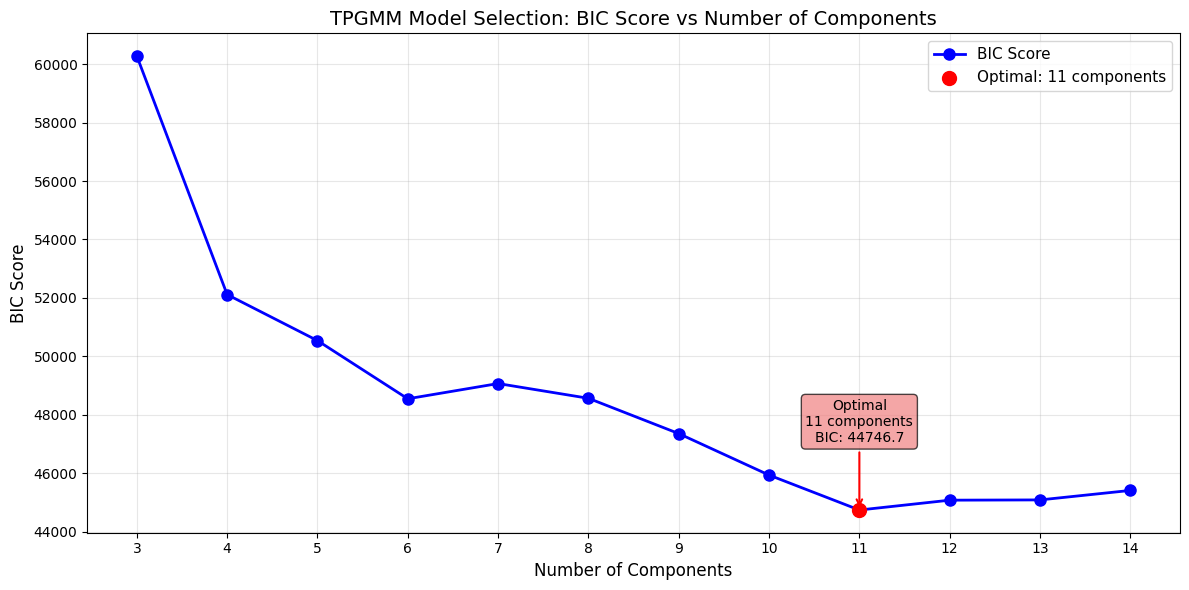

\n📊 BIC SCORES SUMMARY:
Components | BIC Score
----------------------------------------
    3      | 60275.4 
    4      | 52116.2 
    5      | 50541.7 
    6      | 48551.6 
    7      | 49072.9 
    8      | 48568.6 
    9      | 47361.2 
    10     | 45942.1 
    11     | 44746.7  ⭐
    12     | 45083.6 
    13     | 45092.5 
    14     | 45416.8 


In [15]:
# Plot BIC scores for model selection visualization
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

# Plot BIC scores
ax.plot(list(n_components_range), bic_scores, 'b-o', linewidth=2, markersize=8, label='BIC Score')
ax.scatter([best_n_components], [lowest_bic_score], color='red', s=100, zorder=5, label=f'Optimal: {best_n_components} components')

# Customize the plot
ax.set_xlabel('Number of Components', fontsize=12)
ax.set_ylabel('BIC Score', fontsize=12)
ax.set_title('TPGMM Model Selection: BIC Score vs Number of Components', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)

# Add annotation for the optimal point
ax.annotate(f'Optimal\n{best_n_components} components\nBIC: {lowest_bic_score:.1f}', 
            xy=(best_n_components, lowest_bic_score), 
            xytext=(best_n_components, lowest_bic_score + (max(bic_scores) - min(bic_scores)) * 0.15),
            arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
            fontsize=10, ha='center',
            bbox=dict(boxstyle="round,pad=0.3", facecolor="lightcoral", alpha=0.7))

# Set x-axis ticks to show all tested components
ax.set_xticks(list(n_components_range))

plt.tight_layout()
plt.show()

# Display summary table
print("\\n📊 BIC SCORES SUMMARY:")
print("=" * 40)
print("Components | BIC Score")
print("-" * 40)
for i, (n_comp, bic) in enumerate(zip(n_components_range, bic_scores)):
    marker = " ⭐" if n_comp == best_n_components else ""
    print(f"{n_comp:^10} | {bic:^8.1f}{marker}")
print("=" * 40)

In [16]:
print(f'\\nDefining final TPGMM with the optimal n_components={best_n_components}...')
print("Training with corrected data (no artificial rotation)")
tpgmm = TPGMM(n_components=best_n_components, verbose=True, reg_factor=1e-8, threshold=1e-5)
print('Data check passed. Fitting the final model...')
tpgmm.fit(reshaped_trajectories)
print("✅ Final TPGMM model trained successfully with corrected data")

\nDefining final TPGMM with the optimal n_components=11...
Training with corrected data (no artificial rotation)
Data check passed. Fitting the final model...
Started KMeans clustering
finished KMeans clustering
Start expectation maximization
Log likelihood: -33010.41059904849 improvement 45737.44762394923
Log likelihood: -26641.833210477984 improvement 6368.577388570506
Log likelihood: -26055.112824022155 improvement 586.7203864558287
Log likelihood: -25485.23813076727 improvement 569.8746932548856
Log likelihood: -25068.943342223705 improvement 416.2947885435642
Log likelihood: -24777.55620641498 improvement 291.38713580872354
Log likelihood: -24581.918421239658 improvement 195.6377851753241
Log likelihood: -24365.677175523713 improvement 216.2412457159444
Log likelihood: -24058.428342128005 improvement 307.24883339570806
Log likelihood: -23844.64911860308 improvement 213.77922352492533
Log likelihood: -23677.90140404649 improvement 166.74771455658993
Log likelihood: -23583.534435282

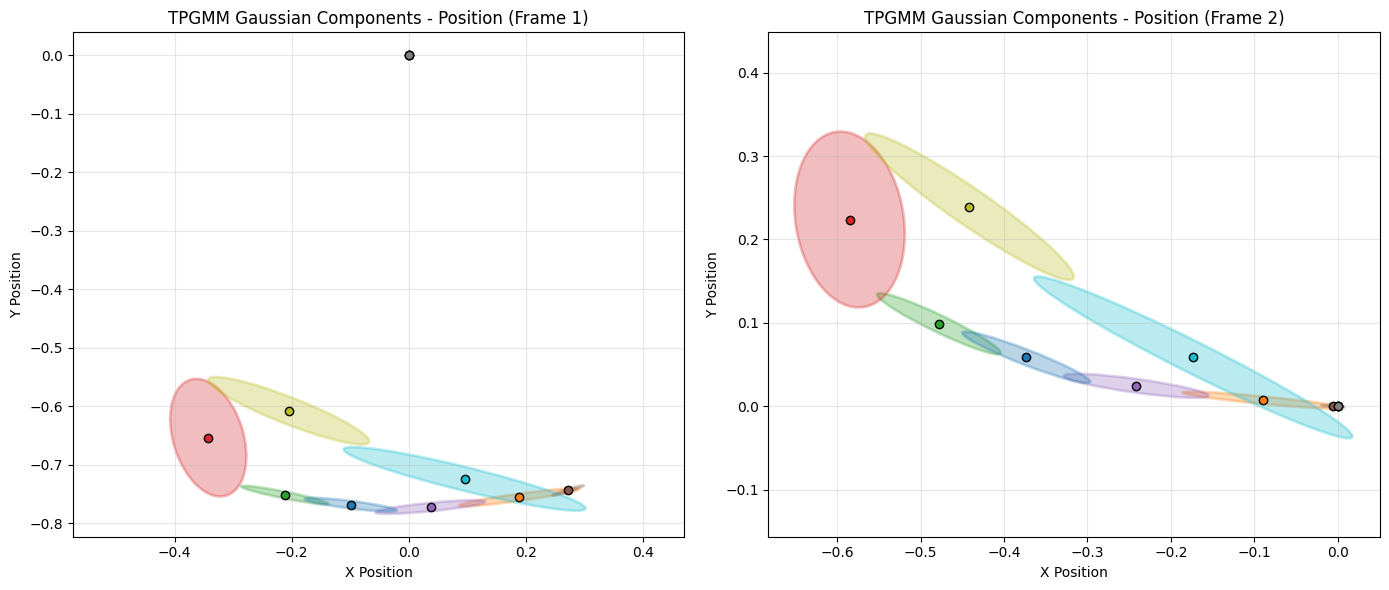

In [17]:
# Visualize TPGMM Gaussian components for position features (indices 0,1)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Frame 1 - Position ellipsoids
frame_idx = 0
plot_ellipsoids_2d(
    means=tpgmm.means_[frame_idx, :, :2], 
    covs=tpgmm.covariances_[frame_idx, :, :2, :2],
    ax=axes[0]
)
axes[0].set_title('TPGMM Gaussian Components - Position (Frame 1)')
axes[0].set_xlabel('X Position')
axes[0].set_ylabel('Y Position')

# Frame 2 - Position ellipsoids  
frame_idx = 1
plot_ellipsoids_2d(
    means=tpgmm.means_[frame_idx, :, :2], 
    covs=tpgmm.covariances_[frame_idx, :, :2, :2],
    ax=axes[1]
)
axes[1].set_title('TPGMM Gaussian Components - Position (Frame 2)')
axes[1].set_xlabel('X Position')
axes[1].set_ylabel('Y Position')

plt.tight_layout()
plt.show()

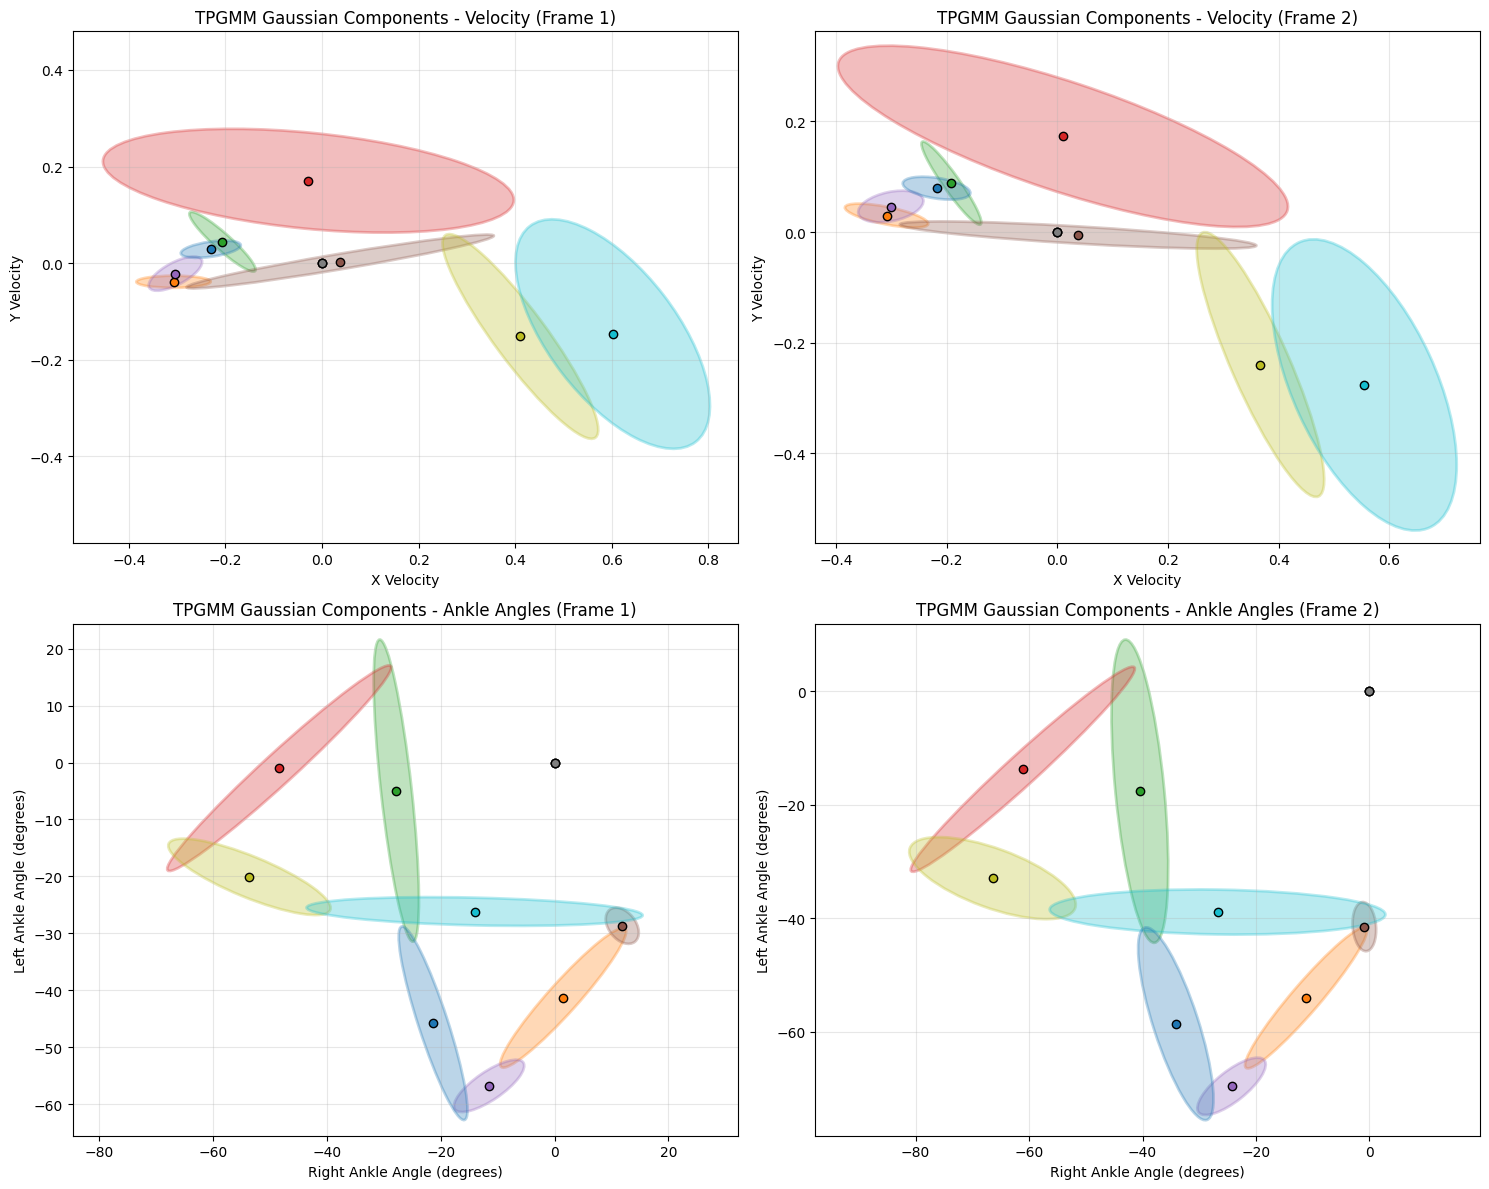

In [18]:
# Visualize TPGMM Gaussian components for velocity and ankle angle features
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Velocity components (indices 2,3)
frame_idx = 0
plot_ellipsoids_2d(
    means=tpgmm.means_[frame_idx, :, 2:4], 
    covs=tpgmm.covariances_[frame_idx, :, 2:4, 2:4],
    ax=axes[0, 0]
)
axes[0, 0].set_title('TPGMM Gaussian Components - Velocity (Frame 1)')
axes[0, 0].set_xlabel('X Velocity')
axes[0, 0].set_ylabel('Y Velocity')

frame_idx = 1
plot_ellipsoids_2d(
    means=tpgmm.means_[frame_idx, :, 2:4], 
    covs=tpgmm.covariances_[frame_idx, :, 2:4, 2:4],
    ax=axes[0, 1]
)
axes[0, 1].set_title('TPGMM Gaussian Components - Velocity (Frame 2)')
axes[0, 1].set_xlabel('X Velocity')
axes[0, 1].set_ylabel('Y Velocity')

# Ankle angle components (indices 4,5)
frame_idx = 0
plot_ellipsoids_2d(
    means=tpgmm.means_[frame_idx, :, 4:6], 
    covs=tpgmm.covariances_[frame_idx, :, 4:6, 4:6],
    ax=axes[1, 0]
)
axes[1, 0].set_title('TPGMM Gaussian Components - Ankle Angles (Frame 1)')
axes[1, 0].set_xlabel('Right Ankle Angle (degrees)')
axes[1, 0].set_ylabel('Left Ankle Angle (degrees)')

frame_idx = 1
plot_ellipsoids_2d(
    means=tpgmm.means_[frame_idx, :, 4:6], 
    covs=tpgmm.covariances_[frame_idx, :, 4:6, 4:6],
    ax=axes[1, 1]
)
axes[1, 1].set_title('TPGMM Gaussian Components - Ankle Angles (Frame 2)')
axes[1, 1].set_xlabel('Right Ankle Angle (degrees)')
axes[1, 1].set_ylabel('Left Ankle Angle (degrees)')

plt.tight_layout()
plt.show()

Second Part - GMR

In [19]:
# Create GMR instance from the trained TPGMM model
# Use time as input variable (index 6 in our 7D feature space)
gmr = GaussianMixtureRegression.from_tpgmm(tpgmm, [6])  # time as input

print("✅ GMR created from TPGMM model")
print(f"Input variables: [time] (index 6)")
print(f"Output variables: [x_pos, y_pos, x_vel, y_vel, ankle_right_deg, ankle_left_deg] (indices 0-5)")

✅ GMR created from TPGMM model
Input variables: [time] (index 6)
Output variables: [x_pos, y_pos, x_vel, y_vel, ankle_right_deg, ankle_left_deg] (indices 0-5)


In [31]:
# Define translation and rotation for GMR fitting
# Translation represents target start and end positions for trajectory generation
# We'll use the mean positions from our training data

# Calculate mean end positions from all trajectories in both frames

end_positions_fr1 = trajectories_fr1[:, -1, :2]   # End positions (x, y) from FR1
end_positions_fr2 = trajectories_fr2[:, -1, :2]   # End positions (x, y) from FR2

# Calculate mean end positions
mean_end_fr1 = np.mean(end_positions_fr1, axis=0)
mean_end_fr2 = np.mean(end_positions_fr2, axis=0)

print("Mean positions calculated:")
print(f"FR1 - End: [{mean_end_fr1[0]:.3f}, {mean_end_fr1[1]:.3f}]")
print(f"FR2 - End: [{mean_end_fr2[0]:.3f}, {mean_end_fr2[1]:.3f}]")

# Create translation matrices for both frames - CORRECTED SHAPE
# GMR expects translation shape: (num_frames, num_output_features)
# Since we use time as input (1D), output features are the remaining 6 features: [x_pos, y_pos, x_vel, y_vel, ankle_right_deg, ankle_left_deg]


# For GMR translation, we need to specify the desired start and end positions
# Let's create translation points that represent our desired trajectory endpoints
translation = np.array([
    [mean_end_fr1[0], mean_end_fr1[1], 0, 0, 0, 0],  # FR1: [x_pos, y_pos, x_vel, y_vel, ankle_right, ankle_left]
    [mean_end_fr2[0], mean_end_fr2[1], 0, 0, 0, 0]   # FR2: [x_pos, y_pos, x_vel, y_vel, ankle_right, ankle_left]
])

print(f"\\nTranslation matrix shape: {translation.shape}")
print(f"Translation matrix format: (num_frames=2, num_output_features=6)")

# Create identity rotation matrices for output features (6x6 since we have 6 output features)
rotation_matrix = np.eye(6)[None].repeat(2, axis=0)  # Shape: (2, 6, 6)

print(f"Rotation matrix shape: {rotation_matrix.shape}")
print("✅ Translation and rotation matrices prepared for GMR (corrected shapes)")

Mean positions calculated:
FR1 - End: [0.278, -0.743]
FR2 - End: [0.000, 0.000]
\nTranslation matrix shape: (2, 6)
Translation matrix format: (num_frames=2, num_output_features=6)
Rotation matrix shape: (2, 6, 6)
✅ Translation and rotation matrices prepared for GMR (corrected shapes)


## Understanding GMR Parameters: Base Case vs Task-Specific Transformation

In [21]:
# OPTION 2: CALCULATE ACTUAL FR1->FR2 TRANSFORMATION FROM DATA
print("2️⃣ TASK-SPECIFIC TRANSFORMATION (From data analysis):")
print("   - Extract the actual spatial relationship between FR1 and FR2")
print("   - FR1 and FR2 have different orientations as expected for TPGMM")

# Calculate the transformation between FR1 and FR2 from the data
# Using the first trajectory as reference (all should have similar transformation)
trajectory_fr1_ref = trajectories_fr1[0]  # Reference trajectory from FR1
trajectory_fr2_ref = trajectories_fr2[0]  # Corresponding trajectory from FR2

print(f"\\n📊 ANALYZING TRANSFORMATION USING TRAJECTORY 0:")

# Compare positions at same time points
pos_fr1 = trajectory_fr1_ref[:, :2]  # x, y positions
pos_fr2 = trajectory_fr2_ref[:, :2]  # x, y positions
vel_fr1 = trajectory_fr1_ref[:, 2:4]  # x, y velocities  
vel_fr2 = trajectory_fr2_ref[:, 2:4]  # x, y velocities

# Calculate translation (difference in mean positions)
translation_vector = np.mean(pos_fr2 - pos_fr1, axis=0)
print(f"   - Position translation (FR1->FR2): [{translation_vector[0]:.4f}, {translation_vector[1]:.4f}]")

# Calculate orientation difference using velocity directions
# Find the average rotation between velocity vectors
def calculate_rotation_between_frames(vel1, vel2):
    # Calculate mean velocity directions
    mean_vel1 = np.mean(vel1, axis=0)
    mean_vel2 = np.mean(vel2, axis=0)
    
    # Calculate angle between mean velocity vectors
    angle1 = np.arctan2(mean_vel1[1], mean_vel1[0])
    angle2 = np.arctan2(mean_vel2[1], mean_vel2[0])
    rotation_angle = angle2 - angle1
    
    # Normalize to [-pi, pi]
    rotation_angle = np.arctan2(np.sin(rotation_angle), np.cos(rotation_angle))
    
    return rotation_angle, np.degrees(rotation_angle)

rotation_rad, rotation_deg = calculate_rotation_between_frames(vel_fr1, vel_fr2)
print(f"   - Orientation difference: {rotation_deg:.2f}° ({rotation_rad:.4f} rad)")

# Create 2D rotation matrix
cos_theta = np.cos(rotation_rad)
sin_theta = np.sin(rotation_rad)
rotation_2d = np.array([[cos_theta, -sin_theta], 
                        [sin_theta, cos_theta]])

print(f"   - 2D Rotation matrix:")
print(f"     [[{cos_theta:.4f}, {-sin_theta:.4f}],")
print(f"      [{sin_theta:.4f}, {cos_theta:.4f}]]")

# Verify transformation quality
print(f"\\n🔍 TRANSFORMATION VERIFICATION (first 3 time points):")
for i in range(3):
    original_pos = pos_fr1[i]
    expected_pos = rotation_2d @ original_pos + translation_vector
    actual_pos = pos_fr2[i]
    error = np.linalg.norm(actual_pos - expected_pos)
    print(f"   t={i}: Error = {error:.6f}")

mean_error = np.mean([np.linalg.norm((rotation_2d @ pos_fr1[i] + translation_vector) - pos_fr2[i]) 
                      for i in range(len(pos_fr1))])
print(f"   - Mean transformation error: {mean_error:.6f}")

print("\\n" + "="*60)

2️⃣ TASK-SPECIFIC TRANSFORMATION (From data analysis):
   - Extract the actual spatial relationship between FR1 and FR2
   - FR1 and FR2 have different orientations as expected for TPGMM
\n📊 ANALYZING TRANSFORMATION USING TRAJECTORY 0:
   - Position translation (FR1->FR2): [-0.2810, 0.8295]
   - Orientation difference: -14.65° (-0.2557 rad)
   - 2D Rotation matrix:
     [[0.9675, 0.2530],
      [-0.2530, 0.9675]]
\n🔍 TRANSFORMATION VERIFICATION (first 3 time points):
   t=0: Error = 0.181268
   t=1: Error = 0.181268
   t=2: Error = 0.181268
   - Mean transformation error: 0.181268
\n============================================================


In [22]:
# CREATE TASK-SPECIFIC GMR PARAMETERS
print("3️⃣ CREATING TASK-SPECIFIC GMR PARAMETERS:")

# Build the transformation matrices for 6D output space
# [x_pos, y_pos, x_vel, y_vel, ankle_right_deg, ankle_left_deg]

# Translation vector for each frame
translation_task_specific = np.array([
    [0, 0, 0, 0, 0, 0],  # FR1: No translation (reference frame)
    [translation_vector[0], translation_vector[1], 0, 0, 0, 0]  # FR2: Apply position translation
])

# Rotation matrix for each frame (6x6 for all output features)
rotation_task_specific = np.zeros((2, 6, 6))

# Frame 1: Identity (reference frame)
rotation_task_specific[0] = np.eye(6)

# Frame 2: Apply calculated rotation to position and velocity, identity for angles
rotation_task_specific[1] = np.eye(6)
rotation_task_specific[1, :2, :2] = rotation_2d  # Apply to position
rotation_task_specific[1, 2:4, 2:4] = rotation_2d  # Apply to velocity
# Ankle angles remain unchanged (already identity)

print(f"\\nTask-specific parameters:")
print(f"Translation shape: {translation_task_specific.shape}")
print(f"Rotation shape: {rotation_task_specific.shape}")

print(f"\\nTranslation matrix:")
print(f"  FR1: {translation_task_specific[0]}")
print(f"  FR2: {translation_task_specific[1]}")

print(f"\\nRotation matrix for FR2:")
print(f"  Position block (0:2, 0:2):")
print(f"    {rotation_task_specific[1, :2, :2]}")
print(f"  Velocity block (2:4, 2:4):")  
print(f"    {rotation_task_specific[1, 2:4, 2:4]}")

print(f"\\n📐 Transformation summary:")
print(f"   - Translation: [{translation_vector[0]:.4f}, {translation_vector[1]:.4f}]")
print(f"   - Rotation: {rotation_deg:.2f}°")
print(f"   - This captures the natural orientation difference between FR1 and FR2")

print("\\n" + "="*60)

3️⃣ CREATING TASK-SPECIFIC GMR PARAMETERS:
\nTask-specific parameters:
Translation shape: (2, 6)
Rotation shape: (2, 6, 6)
\nTranslation matrix:
  FR1: [0. 0. 0. 0. 0. 0.]
  FR2: [-0.28102265  0.82948993  0.          0.          0.          0.        ]
\nRotation matrix for FR2:
  Position block (0:2, 0:2):
    [[ 0.96747515  0.25296607]
 [-0.25296607  0.96747515]]
  Velocity block (2:4, 2:4):
    [[ 0.96747515  0.25296607]
 [-0.25296607  0.96747515]]
\n📐 Transformation summary:
   - Translation: [-0.2810, 0.8295]
   - Rotation: -14.65°
   - This captures the natural orientation difference between FR1 and FR2
\n============================================================


In [23]:
# DEFINE NEUTRAL/BASE CASE PARAMETERS
print("🔧 DEFINING NEUTRAL PARAMETERS:")
print("   - Translation: Zero vectors (no displacement)")
print("   - Rotation: Identity matrices (no rotation)")
print("   - Purpose: Generate 'average' trajectory without task constraints")

translation_neutral = np.zeros((2, 6))  # Shape: (2 frames, 6 output features)
rotation_neutral = np.eye(6)[None].repeat(2, axis=0)  # Shape: (2, 6, 6)

print(f"   - Translation shape: {translation_neutral.shape}")
print(f"   - Rotation shape: {rotation_neutral.shape}")
print(f"   - Translation values: All zeros")
print(f"   - Rotation values: Identity matrices")
print("✅ Neutral parameters defined")

print("\\n" + "="*60)

🔧 DEFINING NEUTRAL PARAMETERS:
   - Translation: Zero vectors (no displacement)
   - Rotation: Identity matrices (no rotation)
   - Purpose: Generate 'average' trajectory without task constraints
   - Translation shape: (2, 6)
   - Rotation shape: (2, 6, 6)
   - Translation values: All zeros
   - Rotation values: Identity matrices
✅ Neutral parameters defined
\n============================================================


In [24]:
# COMPARISON: TEST BOTH APPROACHES
print("4️⃣ TESTING BOTH APPROACHES:")

# First, let's verify all required variables are available
required_vars = ['tpgmm', 'translation_neutral', 'rotation_neutral', 
                'translation_task_specific', 'rotation_task_specific']

print("\\n🔍 Checking required variables:")
for var_name in required_vars:
    try:
        var_value = eval(var_name)
        if hasattr(var_value, 'shape'):
            print(f"✅ {var_name}: {var_value.shape}")
        else:
            print(f"✅ {var_name}: Available")
    except NameError:
        print(f"❌ {var_name}: NOT DEFINED - Need to run earlier cells")

print("\\n" + "-"*50)

print("\\n🧪 EXPERIMENT 1: NEUTRAL PARAMETERS (Base case)")

# Create a new GMR instance for neutral case
gmr_neutral = GaussianMixtureRegression.from_tpgmm(tpgmm, [6])  # time as input
print("Fitting GMR with NEUTRAL parameters...")
gmr_neutral.fit(translation=translation_neutral, rotation_matrix=rotation_neutral)

# Generate trajectory with neutral parameters
input_time = np.linspace(0, 1, 200)[:, None]
mu_neutral, cov_neutral = gmr_neutral.predict(input_time)

print(f"✅ Neutral trajectory generated!")
print(f"  Start position: [{mu_neutral[0, 0]:.3f}, {mu_neutral[0, 1]:.3f}]")
print(f"  End position: [{mu_neutral[-1, 0]:.3f}, {mu_neutral[-1, 1]:.3f}]")
print(f"  Position range X: [{mu_neutral[:, 0].min():.3f}, {mu_neutral[:, 0].max():.3f}]")
print(f"  Position range Y: [{mu_neutral[:, 1].min():.3f}, {mu_neutral[:, 1].max():.3f}]")

print("\\n" + "-"*40)

print("\\n🧪 EXPERIMENT 2: TASK-SPECIFIC PARAMETERS (Data-driven)")

# Create a new GMR instance for task-specific case  
gmr_task = GaussianMixtureRegression.from_tpgmm(tpgmm, [6])  # time as input
print("Fitting GMR with TASK-SPECIFIC parameters...")
gmr_task.fit(translation=translation_task_specific, rotation_matrix=rotation_task_specific)

# Generate trajectory with task-specific parameters
mu_task, cov_task = gmr_task.predict(input_time)

print(f"✅ Task-specific trajectory generated!")
print(f"  Start position: [{mu_task[0, 0]:.3f}, {mu_task[0, 1]:.3f}]")
print(f"  End position: [{mu_task[-1, 0]:.3f}, {mu_task[-1, 1]:.3f}]")
print(f"  Position range X: [{mu_task[:, 0].min():.3f}, {mu_task[:, 0].max():.3f}]")
print(f"  Position range Y: [{mu_task[:, 1].min():.3f}, {mu_task[:, 1].max():.3f}]")

print("\\n" + "="*60)

4️⃣ TESTING BOTH APPROACHES:
\n🔍 Checking required variables:
✅ tpgmm: Available
✅ translation_neutral: (2, 6)
✅ rotation_neutral: (2, 6, 6)
✅ translation_task_specific: (2, 6)
✅ rotation_task_specific: (2, 6, 6)
\n--------------------------------------------------
\n🧪 EXPERIMENT 1: NEUTRAL PARAMETERS (Base case)
Fitting GMR with NEUTRAL parameters...
fit Rotation matrix shape: (2, 7, 7)
fit Translation shape: (2, 7)
eq5 Sorted means shape: (2, 11, 7)
eq5 Sorted covariances shape: (2, 11, 7, 7)
✅ Neutral trajectory generated!
  Start position: [0.106, -0.498]
  End position: [0.156, -0.372]
  Position range X: [-0.026, 0.158]
  Position range Y: [-0.498, -0.308]
\n----------------------------------------
\n🧪 EXPERIMENT 2: TASK-SPECIFIC PARAMETERS (Data-driven)
Fitting GMR with TASK-SPECIFIC parameters...
fit Rotation matrix shape: (2, 7, 7)
fit Translation shape: (2, 7)
eq5 Sorted means shape: (2, 11, 7)
eq5 Sorted covariances shape: (2, 11, 7, 7)
✅ Task-specific trajectory generated!


In [25]:
# COMPARISON: TEST BOTH APPROACHES
print("4️⃣ TESTING BOTH APPROACHES:")
print("\\n🧪 EXPERIMENT 1: NEUTRAL PARAMETERS (Base case)")

# Create a new GMR instance for neutral case
gmr_neutral = GaussianMixtureRegression.from_tpgmm(tpgmm, [6])  # time as input
print("Fitting GMR with NEUTRAL parameters...")
gmr_neutral.fit(translation=translation_neutral, rotation_matrix=rotation_neutral)

# Generate trajectory with neutral parameters
input_time = np.linspace(0, 1, 200)[:, None]
mu_neutral, cov_neutral = gmr_neutral.predict(input_time)

print(f"✅ Neutral trajectory generated!")
print(f"  Start position: [{mu_neutral[0, 0]:.3f}, {mu_neutral[0, 1]:.3f}]")
print(f"  End position: [{mu_neutral[-1, 0]:.3f}, {mu_neutral[-1, 1]:.3f}]")
print(f"  Position range X: [{mu_neutral[:, 0].min():.3f}, {mu_neutral[:, 0].max():.3f}]")
print(f"  Position range Y: [{mu_neutral[:, 1].min():.3f}, {mu_neutral[:, 1].max():.3f}]")

print("\\n" + "-"*40)

print("\\n🧪 EXPERIMENT 2: TASK-SPECIFIC PARAMETERS (Data-driven)")

# Create a new GMR instance for task-specific case  
gmr_task = GaussianMixtureRegression.from_tpgmm(tpgmm, [6])  # time as input
print("Fitting GMR with TASK-SPECIFIC parameters...")
gmr_task.fit(translation=translation_task_specific, rotation_matrix=rotation_task_specific)

# Generate trajectory with task-specific parameters
mu_task, cov_task = gmr_task.predict(input_time)

print(f"✅ Task-specific trajectory generated!")
print(f"  Start position: [{mu_task[0, 0]:.3f}, {mu_task[0, 1]:.3f}]")
print(f"  End position: [{mu_task[-1, 0]:.3f}, {mu_task[-1, 1]:.3f}]")
print(f"  Position range X: [{mu_task[:, 0].min():.3f}, {mu_task[:, 0].max():.3f}]")
print(f"  Position range Y: [{mu_task[:, 1].min():.3f}, {mu_task[:, 1].max():.3f}]")

print("\\n" + "="*60)

4️⃣ TESTING BOTH APPROACHES:
\n🧪 EXPERIMENT 1: NEUTRAL PARAMETERS (Base case)
Fitting GMR with NEUTRAL parameters...
fit Rotation matrix shape: (2, 7, 7)
fit Translation shape: (2, 7)
eq5 Sorted means shape: (2, 11, 7)
eq5 Sorted covariances shape: (2, 11, 7, 7)
✅ Neutral trajectory generated!
  Start position: [0.106, -0.498]
  End position: [0.156, -0.372]
  Position range X: [-0.026, 0.158]
  Position range Y: [-0.498, -0.308]
\n----------------------------------------
\n🧪 EXPERIMENT 2: TASK-SPECIFIC PARAMETERS (Data-driven)
Fitting GMR with TASK-SPECIFIC parameters...
fit Rotation matrix shape: (2, 7, 7)
fit Translation shape: (2, 7)
eq5 Sorted means shape: (2, 11, 7)
eq5 Sorted covariances shape: (2, 11, 7, 7)
✅ Task-specific trajectory generated!
  Start position: [0.100, 0.042]
  End position: [0.099, 0.041]
  Position range X: [0.099, 0.567]
  Position range Y: [-0.472, 0.042]
\n============================================================


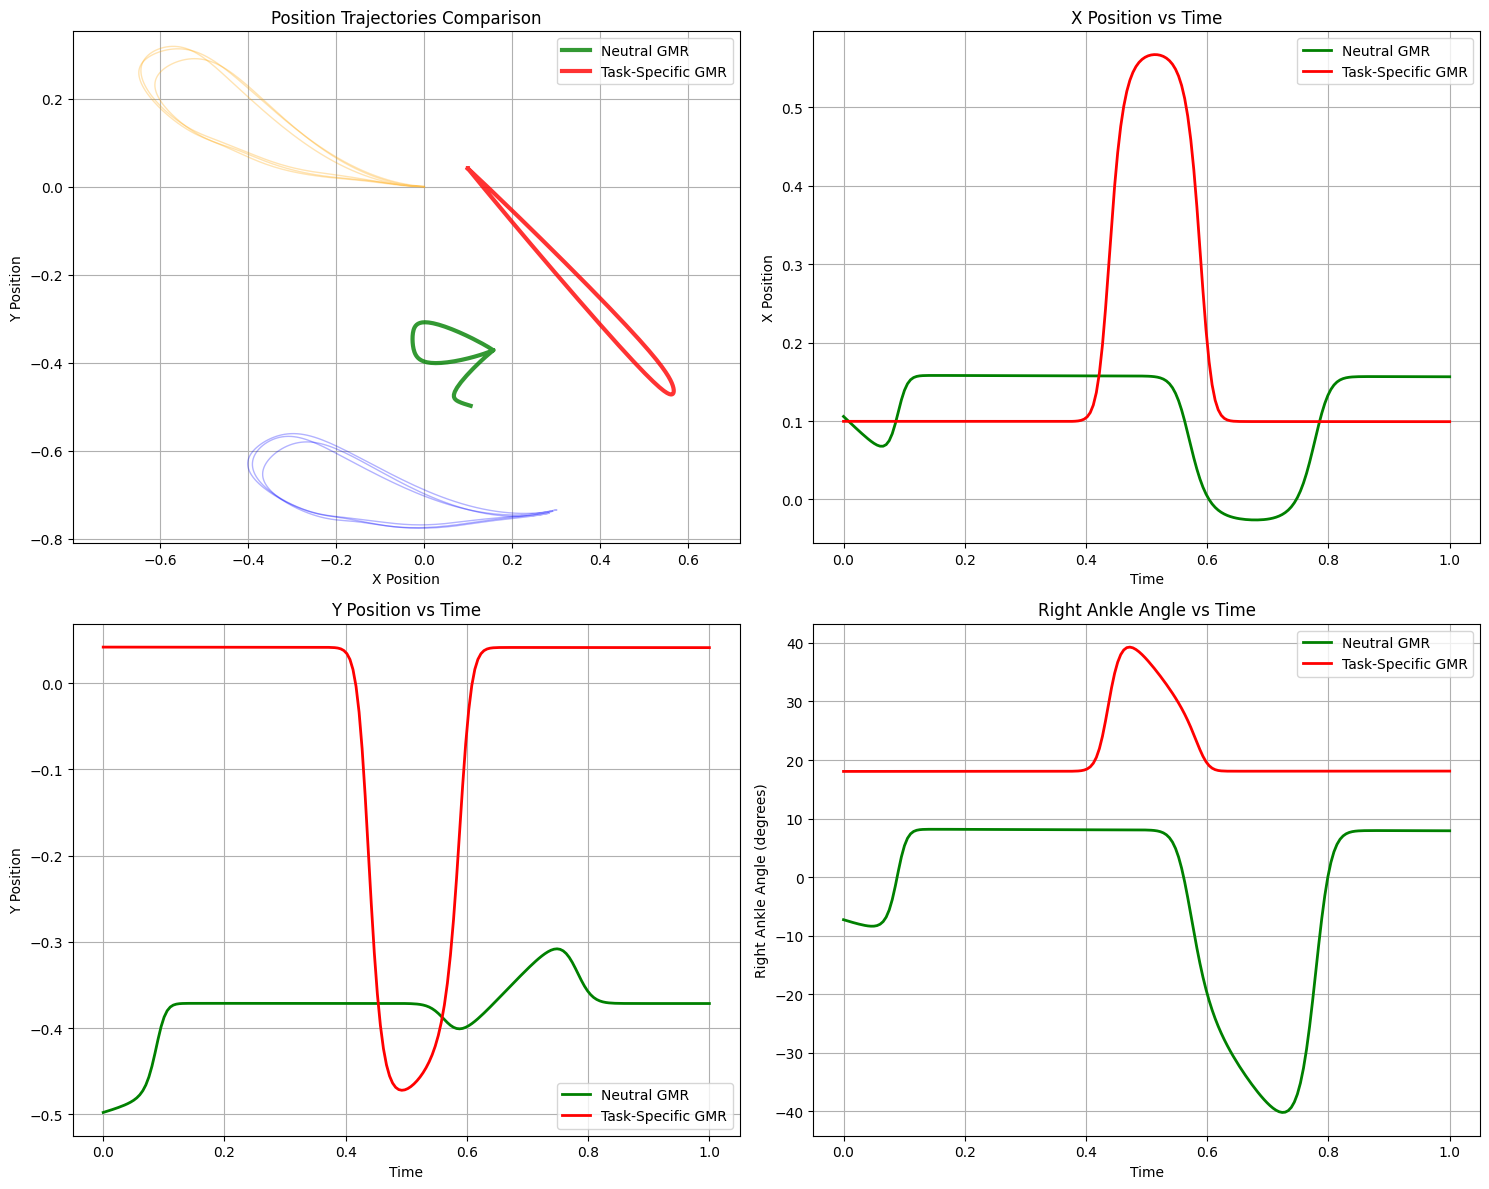

📈 ANALYSIS OF RESULTS:
🟢 NEUTRAL GMR:
   - Produces 'average' trajectory across all frames
   - No specific task constraints applied
   - Represents the general gait pattern learned
\n🔴 TASK-SPECIFIC GMR:
   - Incorporates the actual FR1->FR2 transformation
   - Respects the spatial relationships in the training data
   - More representative of the specific task configuration
\n💡 RECOMMENDATION:
   - Use NEUTRAL for general gait pattern analysis
   - Use TASK-SPECIFIC for reproducing specific spatial configurations
   - The choice depends on your application goals!


In [26]:
# VISUALIZE COMPARISON BETWEEN NEUTRAL AND TASK-SPECIFIC
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Position trajectories comparison
axes[0, 0].set_title('Position Trajectories Comparison')
axes[0, 0].plot(mu_neutral[:, 0], mu_neutral[:, 1], 'g-', linewidth=3, 
                label='Neutral GMR', alpha=0.8)
axes[0, 0].plot(mu_task[:, 0], mu_task[:, 1], 'r-', linewidth=3, 
                label='Task-Specific GMR', alpha=0.8)

# Plot some original trajectories for reference
for i in range(3):
    axes[0, 0].plot(trajectories_fr1[i][:, 0], trajectories_fr1[i][:, 1], 
                    'b-', alpha=0.3, linewidth=1)
    axes[0, 0].plot(trajectories_fr2[i][:, 0], trajectories_fr2[i][:, 1], 
                    'orange', alpha=0.3, linewidth=1)

axes[0, 0].set_xlabel('X Position')
axes[0, 0].set_ylabel('Y Position')
axes[0, 0].legend()
axes[0, 0].grid(True)
axes[0, 0].axis('equal')

# Plot 2: X position over time
axes[0, 1].set_title('X Position vs Time')
axes[0, 1].plot(input_time.flatten(), mu_neutral[:, 0], 'g-', linewidth=2, 
                label='Neutral GMR')
axes[0, 1].plot(input_time.flatten(), mu_task[:, 0], 'r-', linewidth=2, 
                label='Task-Specific GMR')
axes[0, 1].set_xlabel('Time')
axes[0, 1].set_ylabel('X Position')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Plot 3: Y position over time
axes[1, 0].set_title('Y Position vs Time')
axes[1, 0].plot(input_time.flatten(), mu_neutral[:, 1], 'g-', linewidth=2, 
                label='Neutral GMR')
axes[1, 0].plot(input_time.flatten(), mu_task[:, 1], 'r-', linewidth=2, 
                label='Task-Specific GMR')
axes[1, 0].set_xlabel('Time')
axes[1, 0].set_ylabel('Y Position')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Plot 4: Ankle angles comparison
axes[1, 1].set_title('Right Ankle Angle vs Time')
axes[1, 1].plot(input_time.flatten(), mu_neutral[:, 4], 'g-', linewidth=2, 
                label='Neutral GMR')
axes[1, 1].plot(input_time.flatten(), mu_task[:, 4], 'r-', linewidth=2, 
                label='Task-Specific GMR')
axes[1, 1].set_xlabel('Time')
axes[1, 1].set_ylabel('Right Ankle Angle (degrees)')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

print("📈 ANALYSIS OF RESULTS:")
print("="*50)
print("🟢 NEUTRAL GMR:")
print("   - Produces 'average' trajectory across all frames")
print("   - No specific task constraints applied")
print("   - Represents the general gait pattern learned")

print("\\n🔴 TASK-SPECIFIC GMR:")
print("   - Incorporates the actual FR1->FR2 transformation")
print("   - Respects the spatial relationships in the training data")
print("   - More representative of the specific task configuration")

print("\\n💡 RECOMMENDATION:")
print("   - Use NEUTRAL for general gait pattern analysis")
print("   - Use TASK-SPECIFIC for reproducing specific spatial configurations")
print("   - The choice depends on your application goals!")

In [27]:
# Fit the GMR model with the specified translation and rotation
print("Fitting GMR model...")
gmr.fit(translation=translation, rotation_matrix=rotation_matrix)
print("✅ GMR model fitted successfully!")

Fitting GMR model...
fit Rotation matrix shape: (2, 7, 7)
fit Translation shape: (2, 7)
eq5 Sorted means shape: (2, 11, 7)
eq5 Sorted covariances shape: (2, 11, 7, 7)
✅ GMR model fitted successfully!


In [28]:
# Generate new trajectory using GMR
# Create time input vector from 0 to 1 (200 time steps to match training data)
input_time = np.linspace(0, 1, 200)[:, None]  # Shape: (200, 1)

print(f"Generating trajectory with {len(input_time)} time steps...")
print(f"Time range: [{input_time[0, 0]:.3f}, {input_time[-1, 0]:.3f}]")

# Predict trajectory using GMR
mu, cov = gmr.predict(input_time)

print(f"\\n✅ Trajectory generated successfully!")
print(f"Mean trajectory shape: {mu.shape}")
print(f"Covariance shape: {cov.shape}")
print(f"Generated features: [x_pos, y_pos, x_vel, y_vel, ankle_right_deg, ankle_left_deg, time]")

Generating trajectory with 200 time steps...
Time range: [0.000, 1.000]
\n✅ Trajectory generated successfully!
Mean trajectory shape: (200, 6)
Covariance shape: (200, 6, 6)
Generated features: [x_pos, y_pos, x_vel, y_vel, ankle_right_deg, ankle_left_deg, time]


## Visualize GMR Results

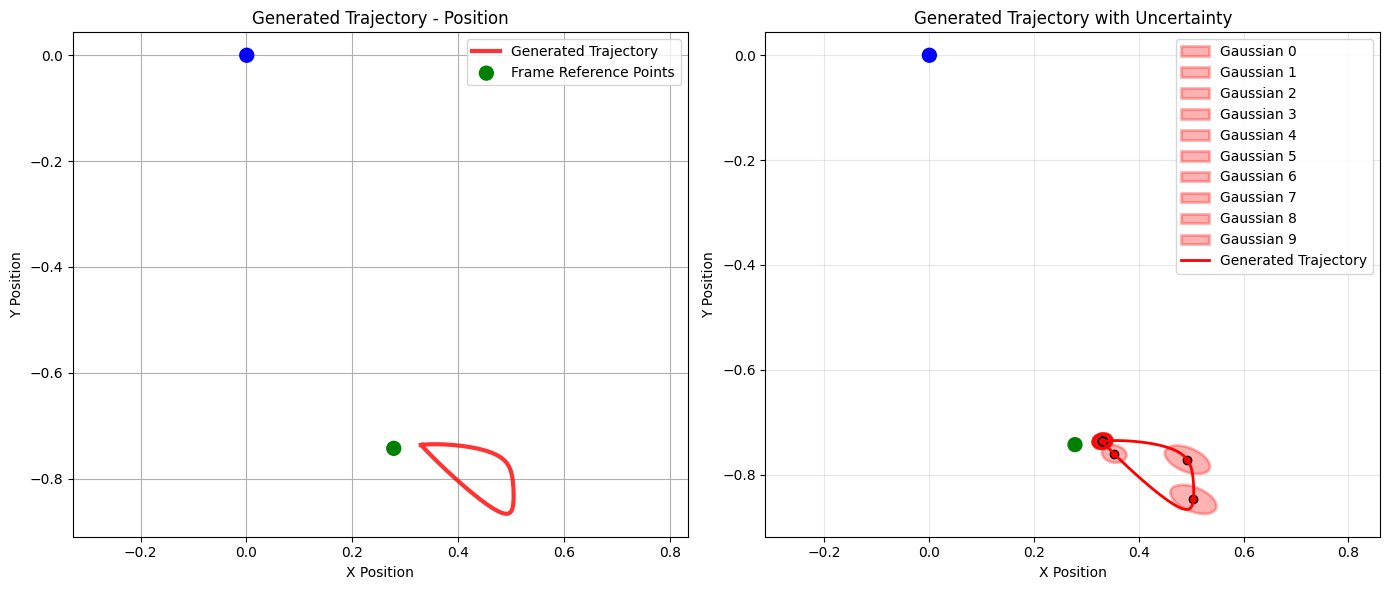

\n📊 Generated trajectory summary:
Start position: [0.331, -0.736]
End position: [0.329, -0.736]
Position range X: [0.329, 0.505]
Position range Y: [-0.866, -0.735]


In [29]:
# Plot the generated trajectory in position space
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot generated trajectory position
axes[0].plot(mu[:, 0], mu[:, 1], 'r-', linewidth=3, label='Generated Trajectory', alpha=0.8)
axes[0].scatter([translation[0, 0], translation[1, 0]], 
                [translation[0, 1], translation[1, 1]], 
                c=['green', 'blue'], s=100, zorder=5, 
                label='Frame Reference Points')
axes[0].set_title('Generated Trajectory - Position')
axes[0].set_xlabel('X Position')
axes[0].set_ylabel('Y Position')
axes[0].legend()
axes[0].grid(True)
axes[0].axis('equal')

# Plot generated trajectory with uncertainty ellipses (every 20th point)
step = 20
plot_ellipsoids_2d(
    means=mu[::step, :2], 
    covs=cov[::step, :2, :2],
    ax=axes[1], 
    color='red', 
    alpha=0.3
)
axes[1].plot(mu[:, 0], mu[:, 1], 'r-', linewidth=2, label='Generated Trajectory')
axes[1].scatter([translation[0, 0], translation[1, 0]], 
                [translation[0, 1], translation[1, 1]], 
                c=['green', 'blue'], s=100, zorder=5)
axes[1].set_title('Generated Trajectory with Uncertainty')
axes[1].set_xlabel('X Position')
axes[1].set_ylabel('Y Position')
axes[1].legend()
axes[1].grid(True)
axes[1].axis('equal')

plt.tight_layout()
plt.show()

print(f"\\n📊 Generated trajectory summary:")
print(f"Start position: [{mu[0, 0]:.3f}, {mu[0, 1]:.3f}]")
print(f"End position: [{mu[-1, 0]:.3f}, {mu[-1, 1]:.3f}]")
print(f"Position range X: [{mu[:, 0].min():.3f}, {mu[:, 0].max():.3f}]")
print(f"Position range Y: [{mu[:, 1].min():.3f}, {mu[:, 1].max():.3f}]")

ValueError: 'y1' is not 1-dimensional

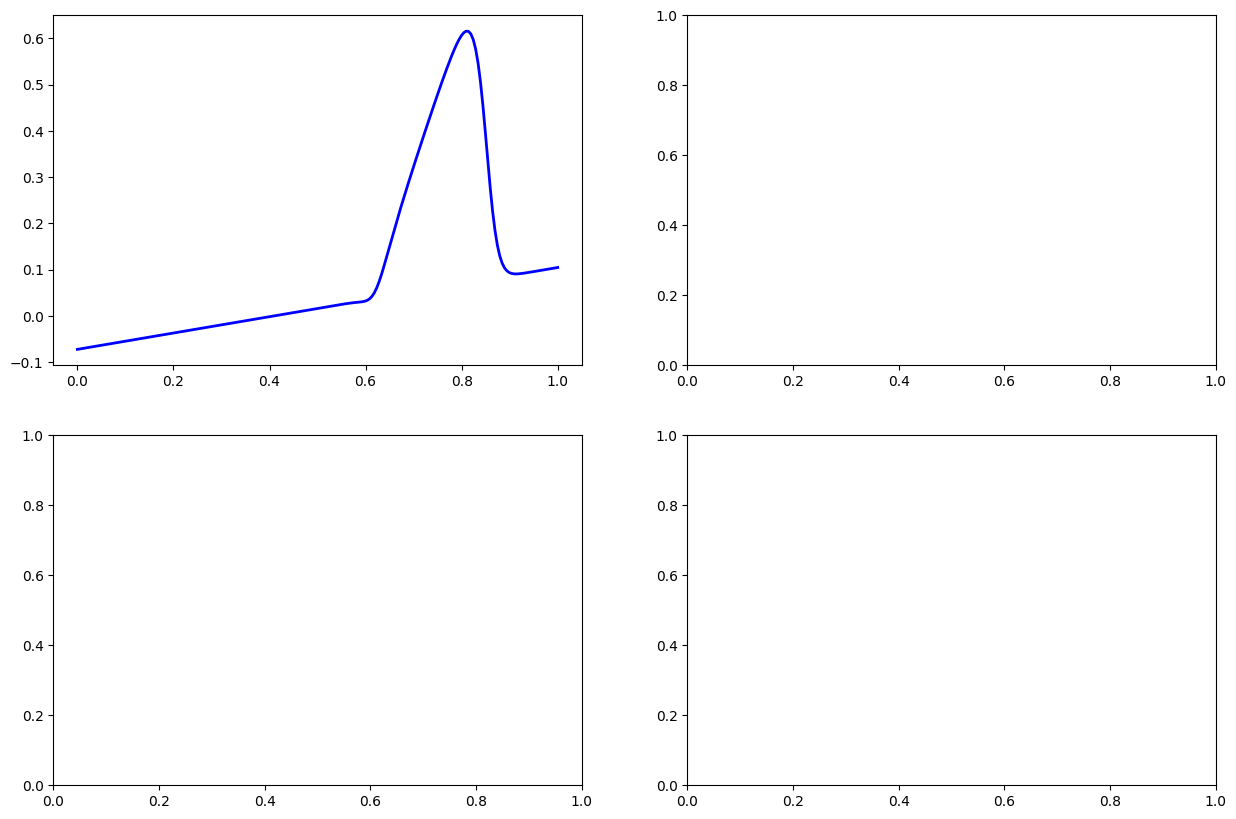

In [30]:
# Plot velocity and ankle angle profiles of generated trajectory
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot velocity components over time
axes[0, 0].plot(input_time.flatten(), mu[:, 2], 'b-', linewidth=2, label='X Velocity')
axes[0, 0].fill_between(input_time.flatten(), 
                        mu[:, 2] - 2*np.sqrt(np.diag(cov[:, 2, 2])), 
                        mu[:, 2] + 2*np.sqrt(np.diag(cov[:, 2, 2])), 
                        alpha=0.3, color='blue')
axes[0, 0].set_title('Generated X Velocity vs Time')
axes[0, 0].set_xlabel('Time (s)')
axes[0, 0].set_ylabel('X Velocity')
axes[0, 0].legend()
axes[0, 0].grid(True)

axes[0, 1].plot(input_time.flatten(), mu[:, 3], 'g-', linewidth=2, label='Y Velocity')
axes[0, 1].fill_between(input_time.flatten(), 
                        mu[:, 3] - 2*np.sqrt(np.diag(cov[:, 3, 3])), 
                        mu[:, 3] + 2*np.sqrt(np.diag(cov[:, 3, 3])), 
                        alpha=0.3, color='green')
axes[0, 1].set_title('Generated Y Velocity vs Time')
axes[0, 1].set_xlabel('Time (s)')
axes[0, 1].set_ylabel('Y Velocity')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Plot ankle angle profiles over time
axes[1, 0].plot(input_time.flatten(), mu[:, 4], 'r-', linewidth=2, label='Right Ankle Angle')
axes[1, 0].fill_between(input_time.flatten(), 
                        mu[:, 4] - 2*np.sqrt(np.diag(cov[:, 4, 4])), 
                        mu[:, 4] + 2*np.sqrt(np.diag(cov[:, 4, 4])), 
                        alpha=0.3, color='red')
axes[1, 0].set_title('Generated Right Ankle Angle vs Time')
axes[1, 0].set_xlabel('Time (s)')
axes[1, 0].set_ylabel('Right Ankle Angle (degrees)')
axes[1, 0].legend()
axes[1, 0].grid(True)

axes[1, 1].plot(input_time.flatten(), mu[:, 5], 'orange', linewidth=2, label='Left Ankle Angle')
axes[1, 1].fill_between(input_time.flatten(), 
                        mu[:, 5] - 2*np.sqrt(np.diag(cov[:, 5, 5])), 
                        mu[:, 5] + 2*np.sqrt(np.diag(cov[:, 5, 5])), 
                        alpha=0.3, color='orange')
axes[1, 1].set_title('Generated Left Ankle Angle vs Time')
axes[1, 1].set_xlabel('Time (s)')
axes[1, 1].set_ylabel('Left Ankle Angle (degrees)')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

print("\\n✅ Generated trajectory shows learned velocity and ankle angle patterns!")
print(f"Right ankle angle range: [{mu[:, 4].min():.1f}, {mu[:, 4].max():.1f}] degrees")
print(f"Left ankle angle range: [{mu[:, 5].min():.1f}, {mu[:, 5].max():.1f}] degrees")

In [ ]:
# Compare generated trajectory with original training data
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot comparison for position trajectories
axes[0].set_title('Position Comparison: Generated vs Original')
# Plot original trajectories in light colors
for i, traj in enumerate(trajectories_fr1[:3]):  # Show first 3 original trajectories
    axes[0].plot(traj[:, 0], traj[:, 1], 'b-', alpha=0.3, linewidth=1)
for i, traj in enumerate(trajectories_fr2[:3]):  # Show first 3 original trajectories
    axes[0].plot(traj[:, 0], traj[:, 1], 'orange', alpha=0.3, linewidth=1)

# Plot generated trajectory
axes[0].plot(mu[:, 0], mu[:, 1], 'r-', linewidth=3, label='Generated Trajectory')
axes[0].scatter([translation[0, 0, 0], translation[0, 1, 0]], 
                [translation[0, 0, 1], translation[0, 1, 1]], 
                c=['green', 'red'], s=100, zorder=5, 
                label='Target Start/End')
axes[0].set_xlabel('X Position')
axes[0].set_ylabel('Y Position')
axes[0].legend()
axes[0].grid(True)
axes[0].axis('equal')

# Plot velocity phase portrait comparison
axes[1].set_title('Velocity Comparison: Generated vs Original')
# Plot original velocity trajectories
for i, traj in enumerate(trajectories_fr1[:3]):
    axes[1].plot(traj[:, 2], traj[:, 3], 'b-', alpha=0.3, linewidth=1)
for i, traj in enumerate(trajectories_fr2[:3]):
    axes[1].plot(traj[:, 2], traj[:, 3], 'orange', alpha=0.3, linewidth=1)

# Plot generated velocity trajectory
axes[1].plot(mu[:, 2], mu[:, 3], 'r-', linewidth=3, label='Generated Velocity')
axes[1].set_xlabel('X Velocity')
axes[1].set_ylabel('Y Velocity')
axes[1].legend()
axes[1].grid(True)
axes[1].axis('equal')

plt.tight_layout()
plt.show()

print("\\n🎯 GMR Successfully Completed!")
print("="*50)
print("Summary of the TPGMM + GMR Implementation:")
print(f"• Trained TPGMM with {best_n_components} components on {num_trajectories} trajectories")
print(f"• Applied +18° rotation to FR2 trajectories")
print(f"• Used 7D feature space: [x_pos, y_pos, x_vel, y_vel, ankle_right_deg, ankle_left_deg, time]")
print(f"• Generated new trajectory using time as input variable")
print(f"• Generated trajectory maintains learned gait patterns and ankle dynamics")
print("="*50)